In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from matplotlib import style
style.use("ggplot")

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


In [2]:
university = pd.read_csv("universities_data.csv")

In [3]:
university.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1534 entries, 0 to 1533
Columns: 145 entries, ID number to Endowment assets (year end) per FTE enrollment (FASB)
dtypes: float64(114), int64(2), object(29)
memory usage: 1.7+ MB


In [4]:
university.columns

Index(['ID number', 'Name', 'year', 'ZIP code', 'Highest degree offered',
       'County name', 'Longitude location of institution',
       'Latitude location of institution', 'Religious affiliation',
       'Offers Less than one year certificate',
       ...
       'Percent of freshmen receiving federal grant aid',
       'Percent of freshmen receiving Pell grants',
       'Percent of freshmen receiving other federal grant aid',
       'Percent of freshmen receiving state/local grant aid',
       'Percent of freshmen receiving institutional grant aid',
       'Percent of freshmen receiving student loan aid',
       'Percent of freshmen receiving federal student loans',
       'Percent of freshmen receiving other loan aid',
       'Endowment assets (year end) per FTE enrollment (GASB)',
       'Endowment assets (year end) per FTE enrollment (FASB)'],
      dtype='object', length=145)

In [5]:
university.head()

,ID number,Name,year,ZIP code,Highest degree offered,County name,Longitude location of institution,Latitude location of institution,Religious affiliation,Offers Less than one year certificate,...,Percent of freshmen receiving federal grant aid,Percent of freshmen receiving Pell grants,Percent of freshmen receiving other federal grant aid,Percent of freshmen receiving state/local grant aid,Percent of freshmen receiving institutional grant aid,Percent of freshmen receiving student loan aid,Percent of freshmen receiving federal student loans,Percent of freshmen receiving other loan aid,Endowment assets (year end) per FTE enrollment (GASB),Endowment assets (year end) per FTE enrollment (FASB)
0,100654,Alabama A & M University,2013,35762,Doctor's degree - research/scholarship,Madison County,"-865,685","3,478,337",Not applicable,Implied no,...,81.0,81.0,7.0,1.0,32.0,89.0,89.0,1.0,NaN,NaN
1,100663,University of Alabama at Birmingham,2013,35294-0110,Doctor's degree - research/scholarship and pro...,Jefferson County,"-868,092","3,350,223",Not applicable,Implied no,...,36.0,36.0,10.0,0.0,60.0,56.0,55.0,5.0,24136.0,NaN
2,100690,Amridge University,2013,36117-3553,Doctor's degree - research/scholarship and pro...,Montgomery County,"-86,174","3,236,261",Churches of Christ,Implied no,...,90.0,90.0,0.0,40.0,90.0,100.0,100.0,0.0,NaN,302.0
3,100706,University of Alabama in Huntsville,2013,35899,Doctor's degree - research/scholarship and pro...,Madison County,"-866,384","3,472,282",Not applicable,Yes,...,31.0,31.0,4.0,1.0,63.0,46.0,46.0,3.0,11502.0,NaN
4,100724,Alabama State University,2013,36104-0271,Doctor's degree - research/scholarship and pro...,Montgomery County,"-862,957","3,236,432",Not applicable,Implied no,...,76.0,76.0,13.0,11.0,34.0,81.0,81.0,0.0,13202.0,NaN


In [6]:
university.duplicated().sum()

0

In [95]:
university.isnull().sum()


ID number                                                   0
Name                                                        0
year                                                        0
ZIP code                                                    0
Highest degree offered                                      0
                                                         ... 
Percent of freshmen receiving student loan aid             42
Percent of freshmen receiving federal student loans        42
Percent of freshmen receiving other loan aid               42
Endowment assets (year end) per FTE enrollment (GASB)    1018
Endowment assets (year end) per FTE enrollment (FASB)     574
Length: 145, dtype: int64

In [8]:
uni_app = university[["Name","Applicants total","Admissions total","Enrolled total"]].sort_values("Applicants total",ascending=False).head(20).dropna()
uni_app

,Name,Applicants total,Admissions total,Enrolled total
84,University of California-Los Angeles,72676.0,15981.0,5620.0
81,University of California-Berkeley,61717.0,11108.0,4162.0
86,University of California-San Diego,60832.0,22812.0,4575.0
841,New York University,57845.0,15066.0,5207.0
83,University of California-Irvine,56515.0,23956.0,5077.0
87,University of California-Santa Barbara,55258.0,24556.0,4741.0
77,California State University-Long Beach,55019.0,16956.0,4276.0
863,St John's University-New York,51634.0,27449.0,2792.0
126,San Diego State University,51163.0,15970.0,4139.0
82,University of California-Davis,49820.0,22526.0,5208.0


Text(0, 0.5, 'Universities')

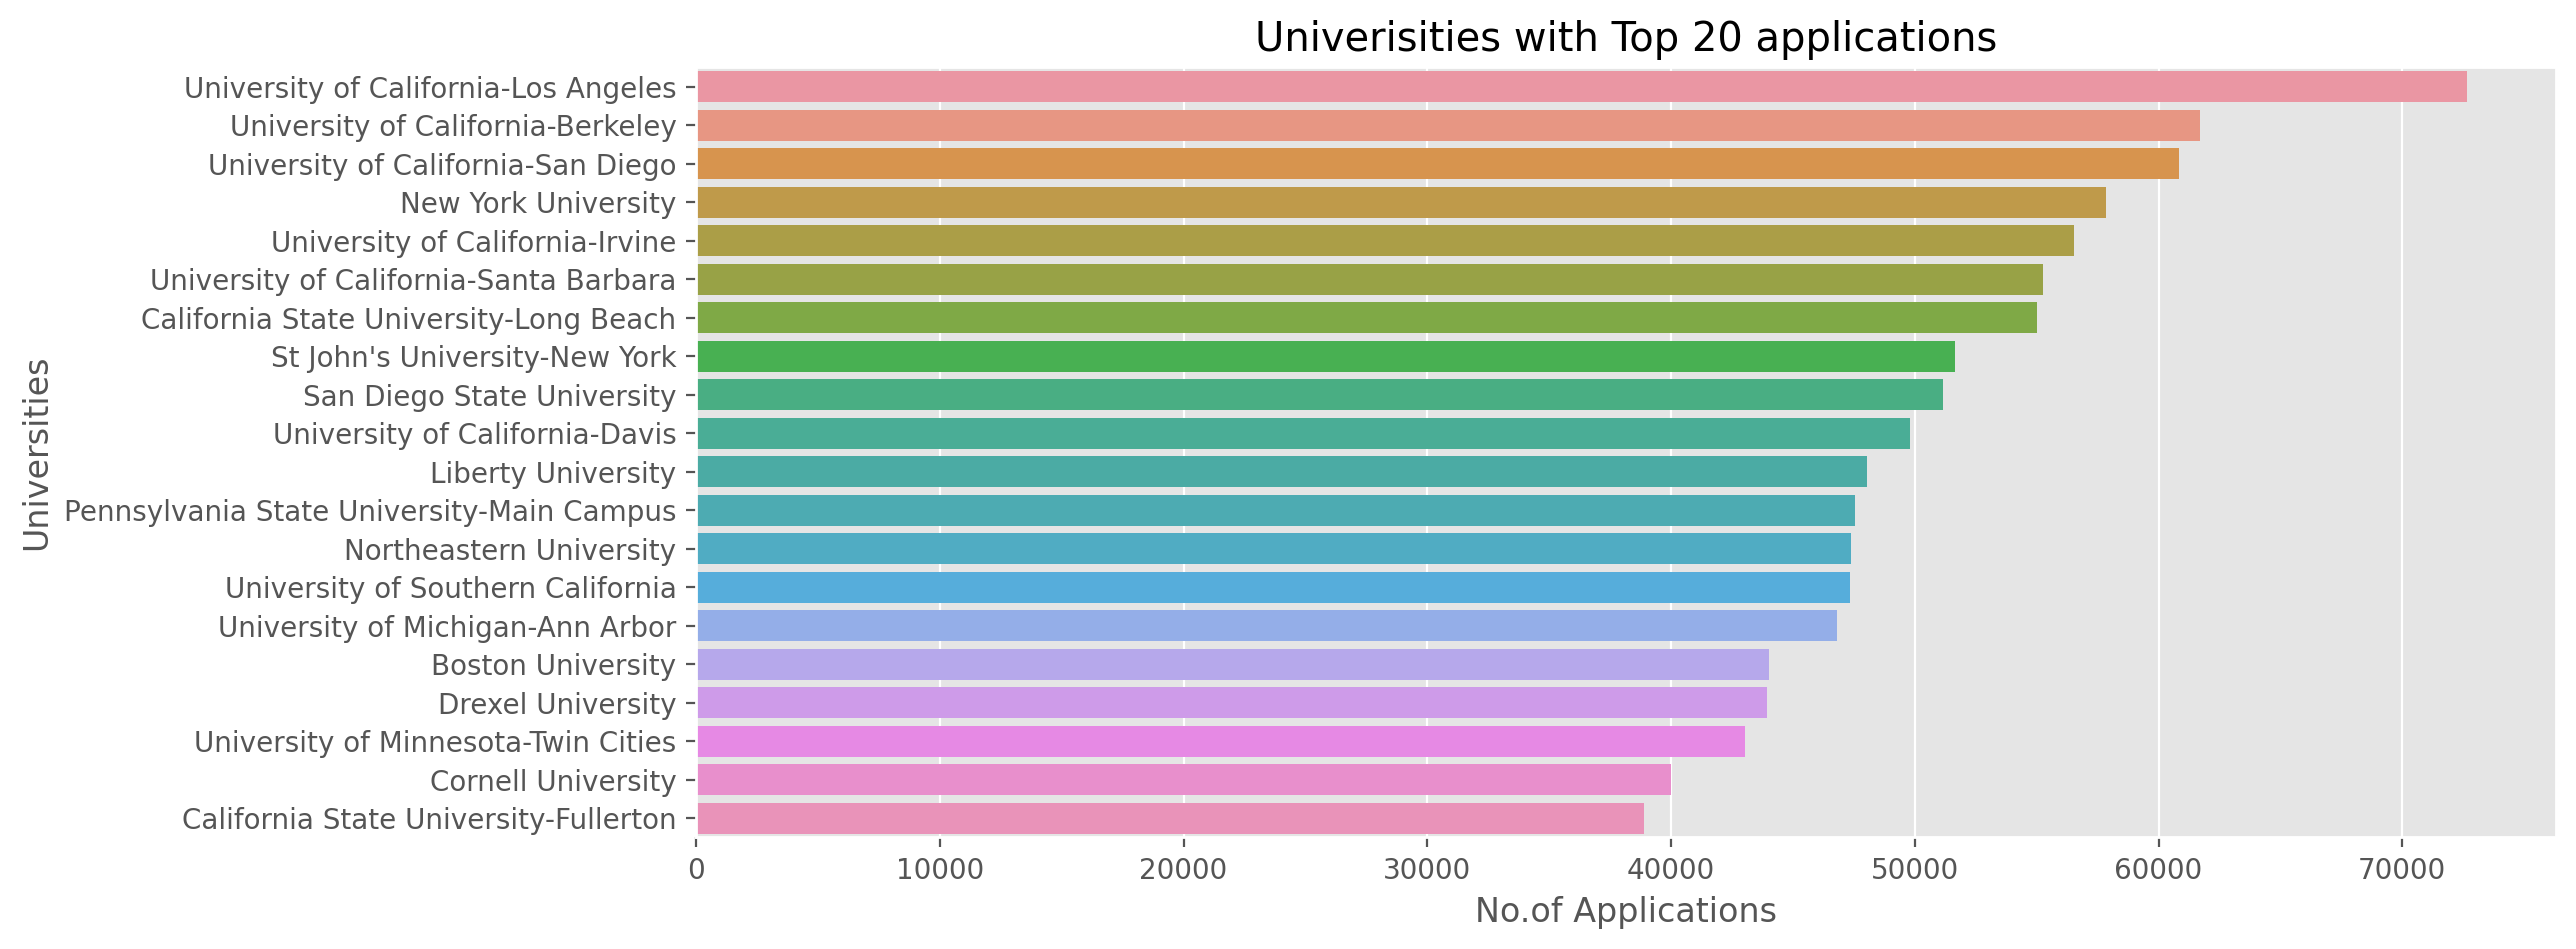

In [9]:
plt.figure(figsize=(12,5),dpi=200)
sns.barplot("Applicants total","Name",data=uni_app)
plt.title("Univerisities with Top 20 applications")
plt.xlabel("No.of Applications")
plt.ylabel("Universities")

In [10]:
uni_enroll = university[["Name","Applicants total","Enrolled total"]].sort_values("Enrolled total",ascending=False).head(20)
uni_enroll

,Name,Applicants total,Enrolled total
1309,Texas A & M University-College Station,31387.0,10241.0
606,Michigan State University,31479.0,8061.0
1133,Pennsylvania State University-Main Campus,47552.0,7649.0
359,Indiana University-Bloomington,37826.0,7604.0
34,University of Arizona,26329.0,7401.0
301,University of Illinois at Urbana-Champaign,33203.0,7329.0
1311,The University of Texas at Austin,38161.0,7249.0
33,Arizona State University-Tempe,21770.0,7171.0
998,Ohio State University-Main Campus,31359.0,7130.0
5,The University of Alabama,30975.0,6454.0


Text(0, 0.5, 'Universities')

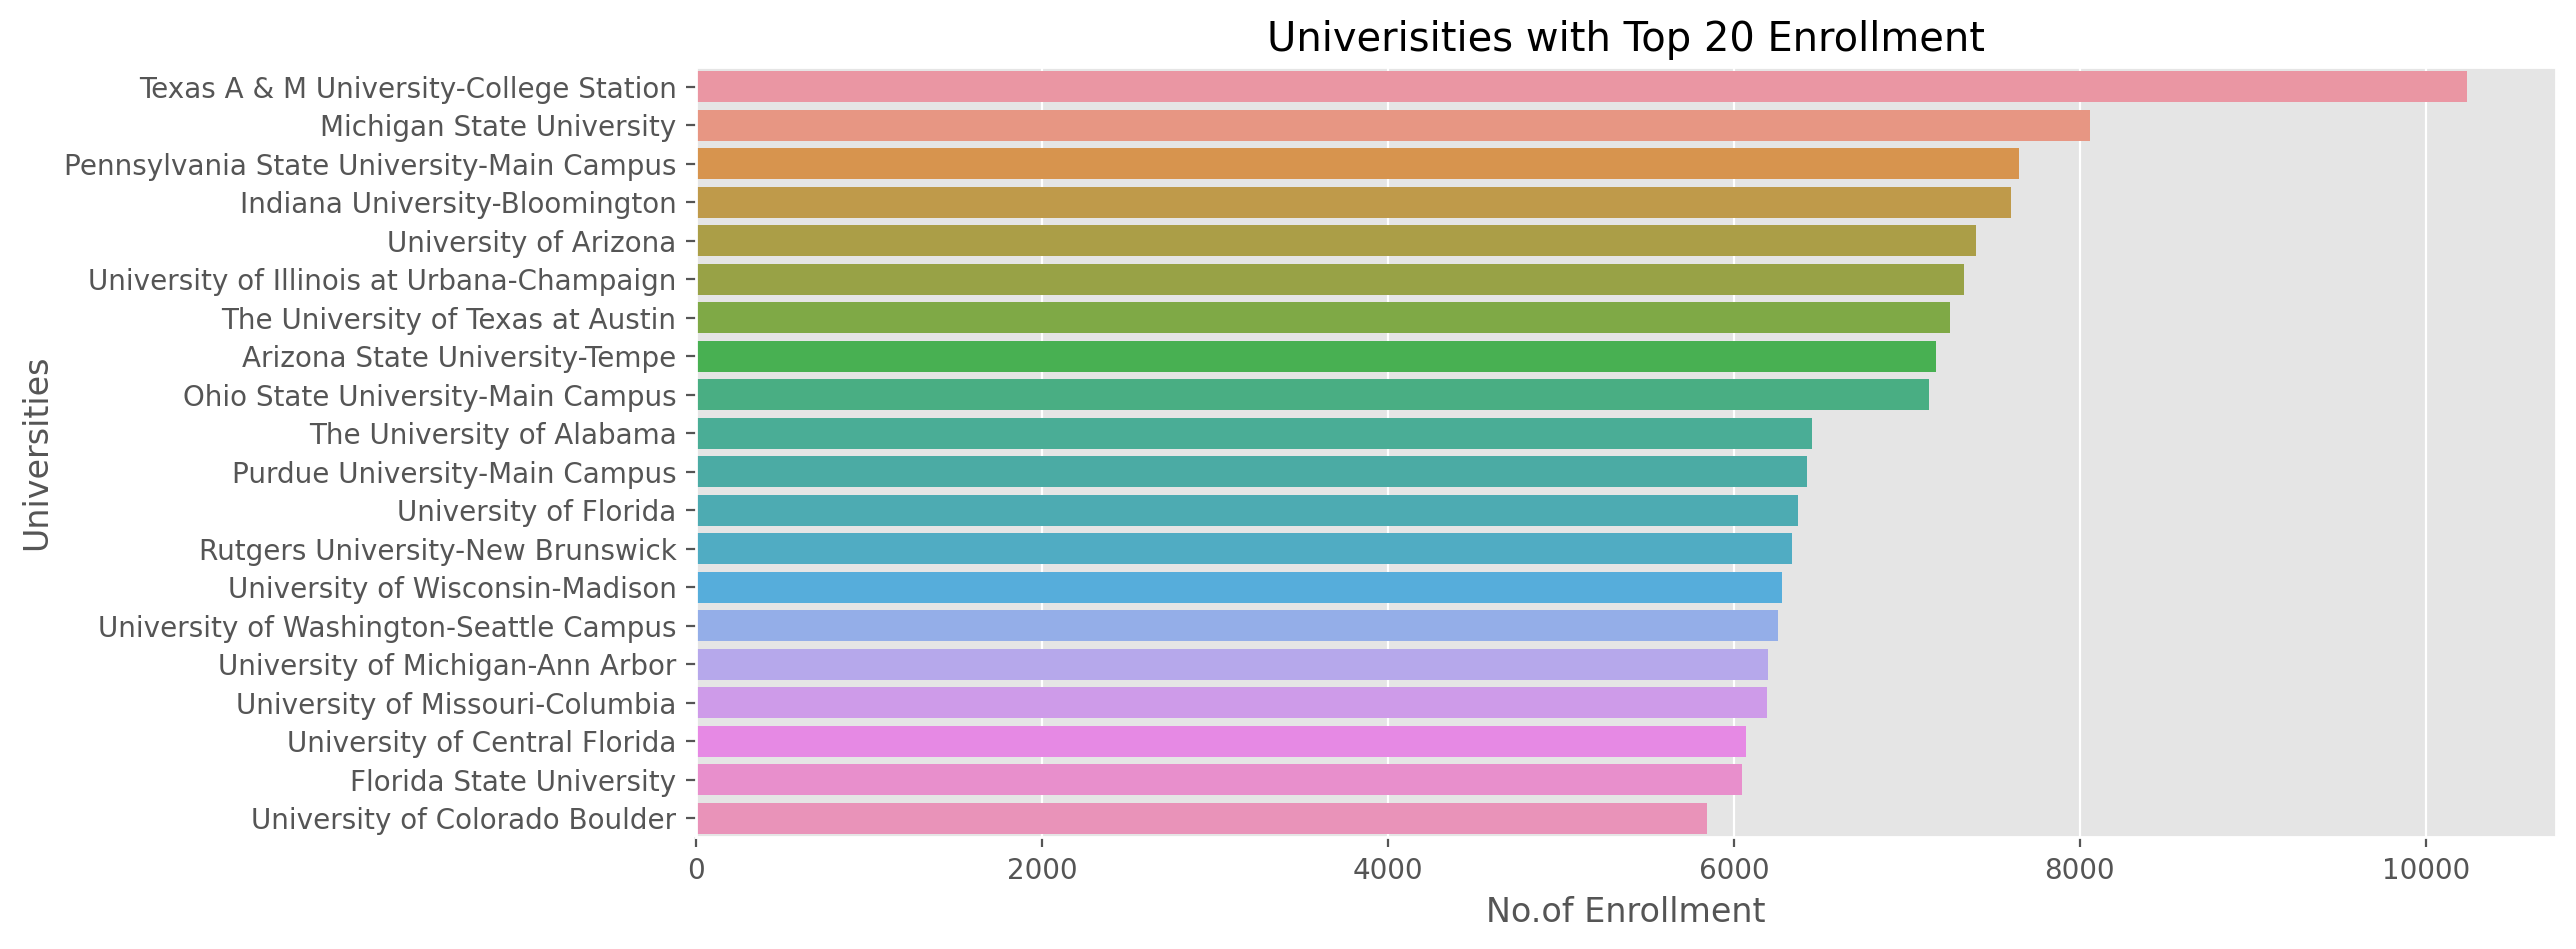

In [11]:
plt.figure(figsize=(12,5),dpi=200)
sns.barplot("Enrolled total","Name",data=uni_enroll)
plt.title("Univerisities with Top 20 Enrollment")
plt.xlabel("No.of Enrollment")
plt.ylabel("Universities")

In [12]:
uni = university[["Name","Applicants total","Enrolled total"]]

In [13]:
uni["enroll percent"]=(uni["Enrolled total"]/uni["Applicants total"])*100

In [14]:
uni.sort_values("Applicants total",ascending=False).head(20)

,Name,Applicants total,Enrolled total,enroll percent
84,University of California-Los Angeles,72676.0,5620.0,7.732952
81,University of California-Berkeley,61717.0,4162.0,6.743685
86,University of California-San Diego,60832.0,4575.0,7.520713
841,New York University,57845.0,5207.0,9.001642
83,University of California-Irvine,56515.0,5077.0,8.983456
87,University of California-Santa Barbara,55258.0,4741.0,8.579753
77,California State University-Long Beach,55019.0,4276.0,7.771861
863,St John's University-New York,51634.0,2792.0,5.407290
126,San Diego State University,51163.0,4139.0,8.089831
82,University of California-Davis,49820.0,5208.0,10.453633


In [15]:
uni.sort_values("enroll percent",ascending=False).head(20)

,Name,Applicants total,Enrolled total,enroll percent
15,University of West Alabama,462.0,380.0,82.251082
213,Keiser University-Ft Lauderdale,4620.0,3658.0,79.177489
1490,Everglades University,67.0,53.0,79.104478
628,Martin Luther College,209.0,164.0,78.468900
1484,Hodges University,221.0,170.0,76.923077
95,Coleman University,82.0,60.0,73.170732
655,Delta State University,472.0,343.0,72.669492
1476,Antioch University-Seattle,42.0,30.0,71.428571
1479,Brandman University,34.0,24.0,70.588235
1485,Remington College-Honolulu Campus,63.0,43.0,68.253968


<AxesSubplot:xlabel='Applicants total', ylabel='enroll percent'>

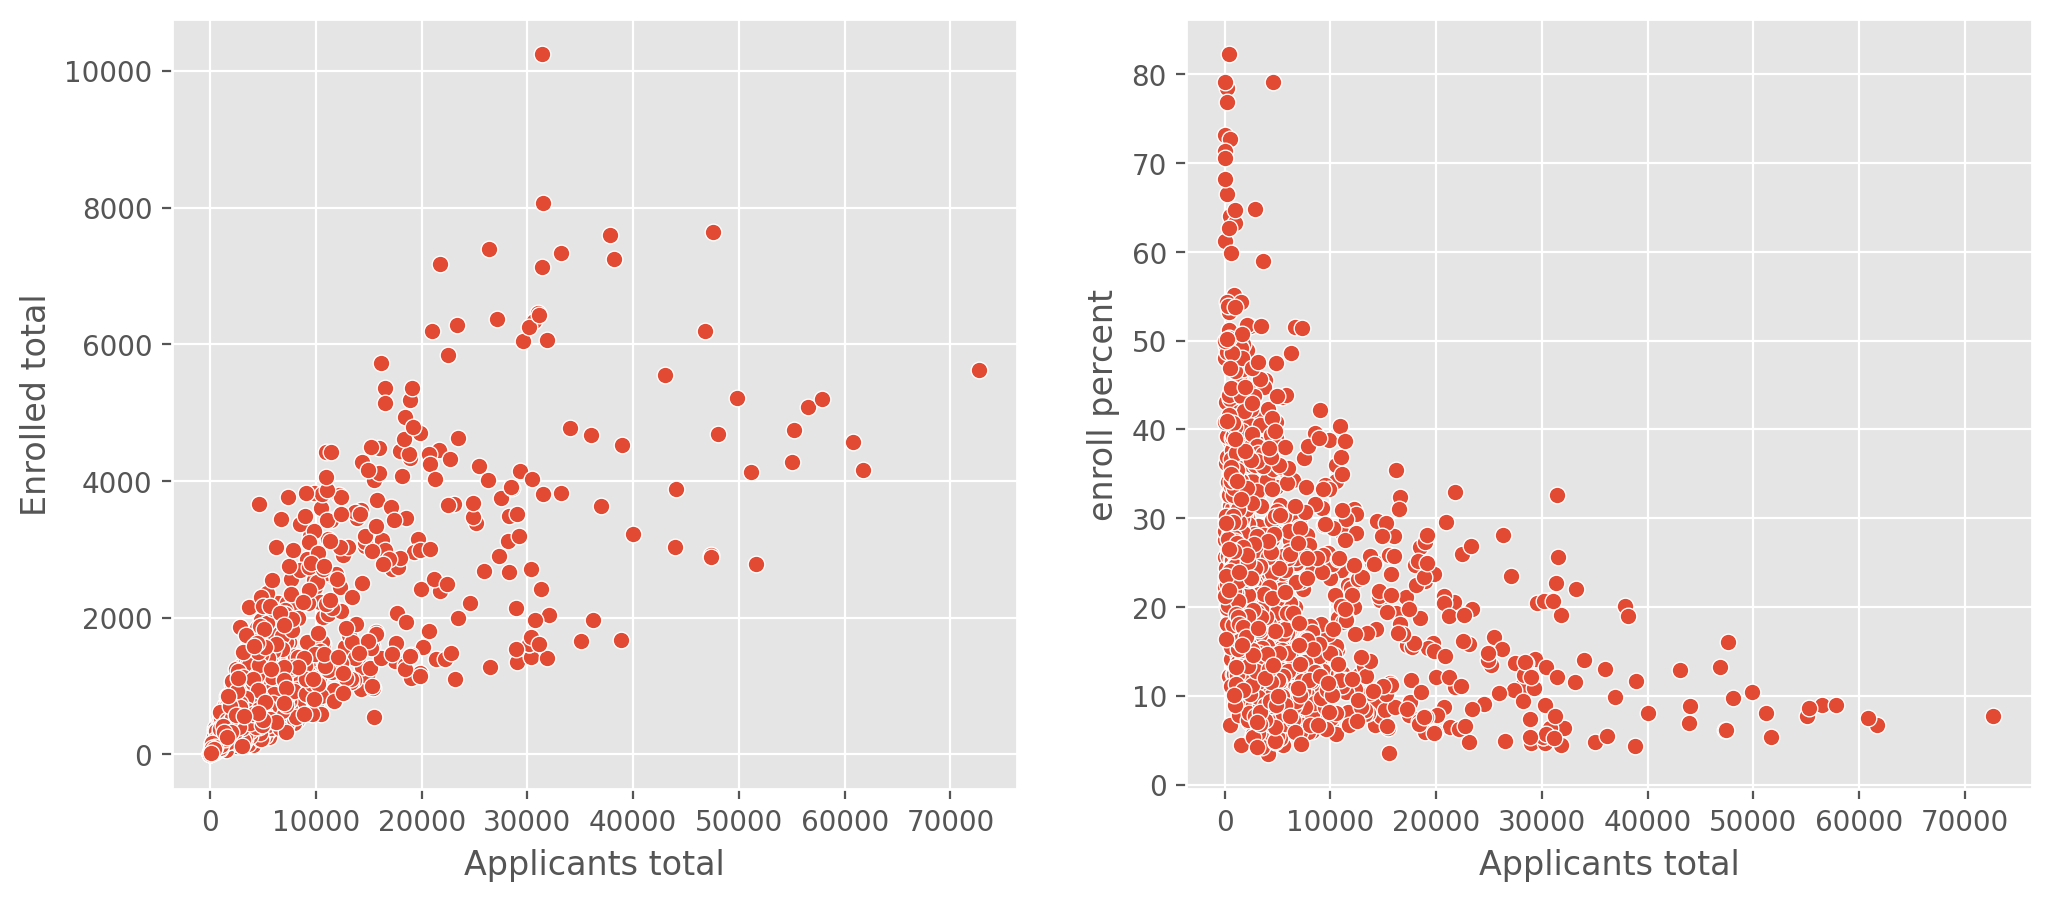

In [16]:
plt.figure(figsize=(12,5),dpi=200)
plt.subplot(1,2,1)
sns.scatterplot("Applicants total","Enrolled total",data=uni)

plt.subplot(1,2,2)
sns.scatterplot("Applicants total","enroll percent",data=uni)

In [17]:
cor_app_enroll=uni[["Applicants total","enroll percent"]].corr()
cor_app_enroll

,Applicants total,enroll percent
Applicants total,1.000000,-0.296748
enroll percent,-0.296748,1.000000


<AxesSubplot:>

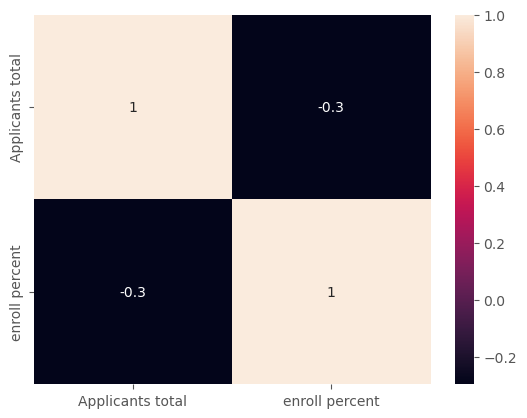

In [18]:
sns.heatmap(uni[["Applicants total","enroll percent"]].corr(),annot=True)

##### here the universities which had less than 10000 applicants has the highest percentage of students enrolled with them compared to the universities having higher applicants.
##### very few universities which had received the applications around 20000-50000 have more than 6000 students enrolled with them.
##### The no.of applications received by the university and the no.of students enrolled with them has very less correlation of -0.3.

In [19]:
uni2=university[["Name","Applicants total","Enrolled total","Admissions total"]]
uni2

,Name,Applicants total,Enrolled total,Admissions total
0,Alabama A & M University,6142.0,1104.0,5521.0
1,University of Alabama at Birmingham,5689.0,1773.0,4934.0
2,Amridge University,NaN,NaN,NaN
3,University of Alabama in Huntsville,2054.0,651.0,1656.0
4,Alabama State University,10245.0,1479.0,5251.0
...,...,...,...,...
1529,University of South Florida-Sarasota-Manatee,393.0,86.0,136.0
1530,The Kingâ€™s College,3033.0,127.0,2158.0
1531,Ottawa University-Online,NaN,NaN,NaN
1532,Providence Christian College,122.0,20.0,65.0


In [20]:
uni2["admit percent"]=(uni2["Admissions total"]/uni2["Applicants total"])*100
uni2["enroll-admit percent"]=(uni2["Enrolled total"]/uni2["Admissions total"])*100

In [21]:
uni2

,Name,Applicants total,Enrolled total,Admissions total,admit percent,enroll-admit percent
0,Alabama A & M University,6142.0,1104.0,5521.0,89.889287,19.996377
1,University of Alabama at Birmingham,5689.0,1773.0,4934.0,86.728775,35.934333
2,Amridge University,NaN,NaN,NaN,NaN,NaN
3,University of Alabama in Huntsville,2054.0,651.0,1656.0,80.623174,39.311594
4,Alabama State University,10245.0,1479.0,5251.0,51.254270,28.166064
...,...,...,...,...,...,...
1529,University of South Florida-Sarasota-Manatee,393.0,86.0,136.0,34.605598,63.235294
1530,The Kingâ€™s College,3033.0,127.0,2158.0,71.150676,5.885079
1531,Ottawa University-Online,NaN,NaN,NaN,NaN,NaN
1532,Providence Christian College,122.0,20.0,65.0,53.278689,30.769231


In [22]:
uni2[["admit percent","enroll-admit percent"]].corr()

,admit percent,enroll-admit percent
admit percent,1.000000,-0.071669
enroll-admit percent,-0.071669,1.000000


<AxesSubplot:>

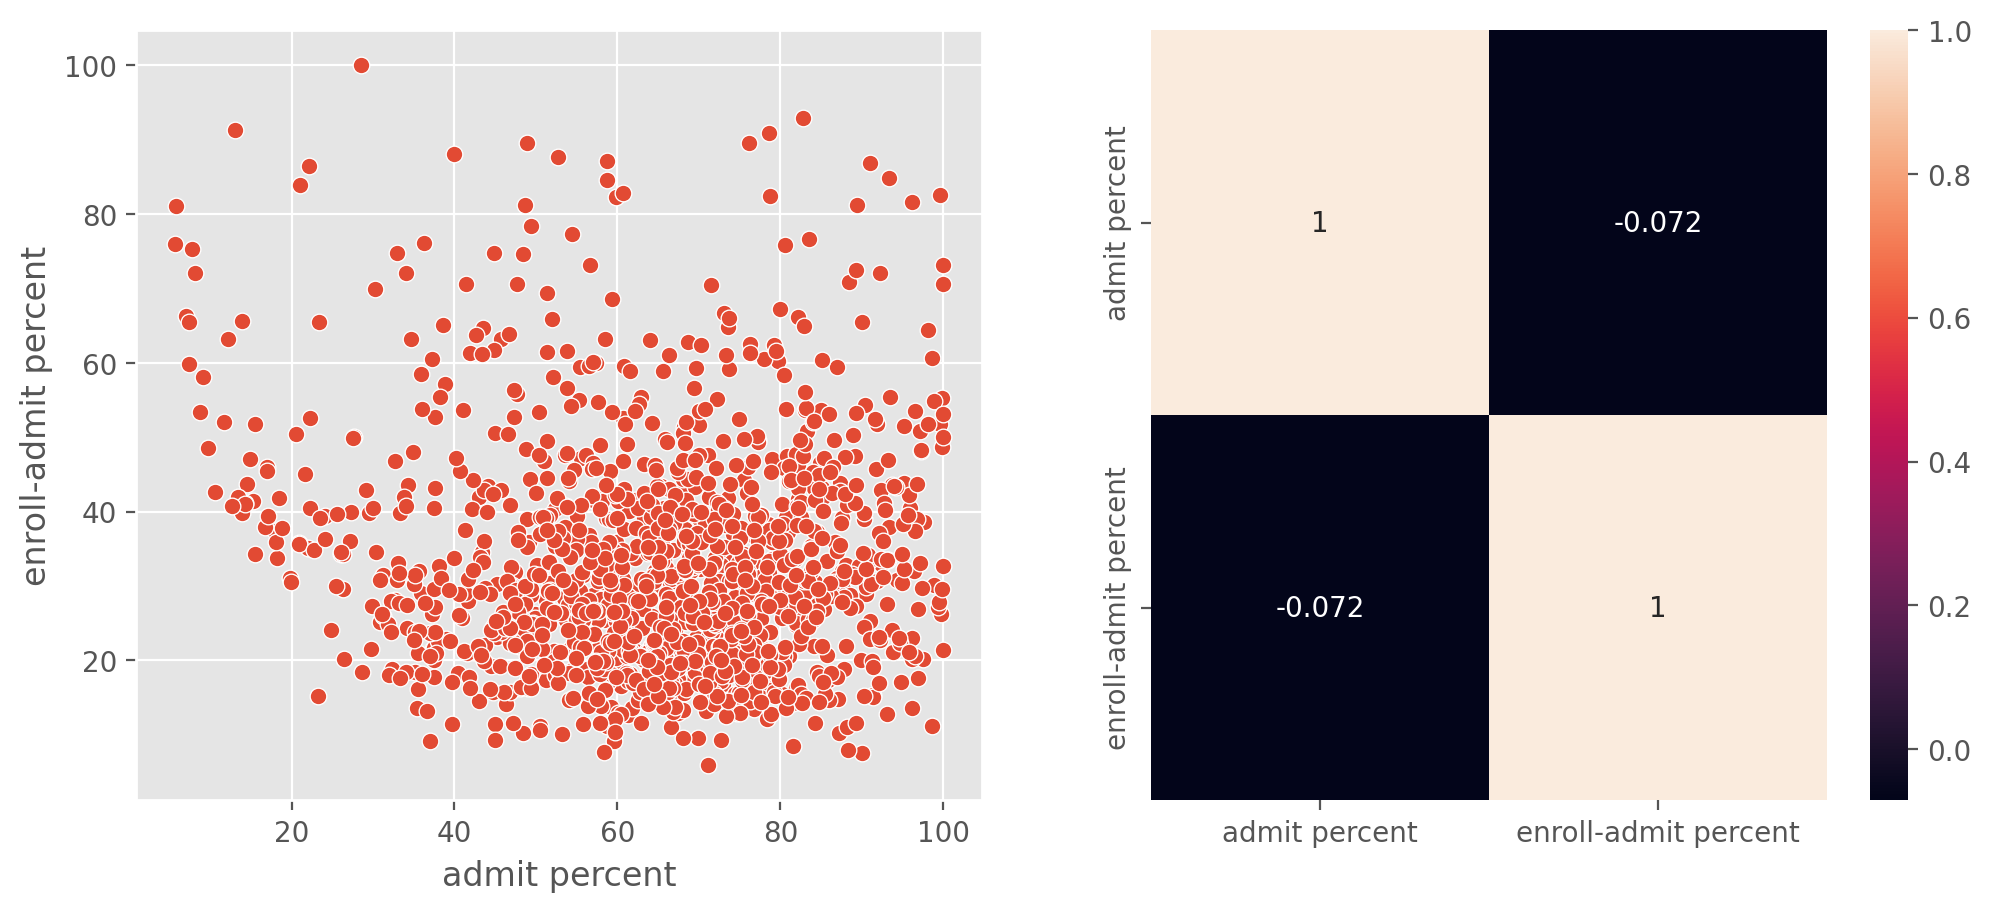

In [23]:
plt.figure(figsize=(12,5),dpi=200)
plt.subplot(1,2,1)
sns.scatterplot("admit percent","enroll-admit percent",data=uni2)

plt.subplot(1,2,2)
sns.heatmap(uni2[["admit percent","enroll-admit percent"]].corr(),annot=True)

In [24]:
sorted_enroll_high=uni2.sort_values("admit percent",ascending=False).head(50)
sorted_enroll_high

,Name,Applicants total,Enrolled total,Admissions total,admit percent,enroll-admit percent
451,University of Pikeville,1804.0,386.0,1804.0,100.000000,21.396896
633,Metropolitan State University,306.0,100.0,306.0,100.000000,32.679739
1479,Brandman University,34.0,24.0,34.0,100.000000,70.588235
95,Coleman University,82.0,60.0,82.0,100.000000,73.170732
1343,Goddard College,4.0,2.0,4.0,100.000000,50.000000
709,Montana State University-Northern,376.0,200.0,376.0,100.000000,53.191489
1385,Southern Virginia University,763.0,226.0,762.0,99.868938,29.658793
1313,The University of Texas at El Paso,6240.0,3033.0,6228.0,99.807692,48.699422
281,Lewis-Clark State College,861.0,475.0,859.0,99.767712,55.296857
799,College of Staten Island CUNY,9785.0,2556.0,9761.0,99.754727,26.185842


In [25]:
sorted_enroll_low=uni2.sort_values("admit percent").head(50)
sorted_enroll_low

,Name,Applicants total,Enrolled total,Admissions total,admit percent,enroll-admit percent
1469,Stanford University,38828.0,1677.0,2208.0,5.686618,75.951087
544,Harvard University,35023.0,1659.0,2047.0,5.844731,81.045432
179,Yale University,28977.0,1356.0,2043.0,7.050419,66.372981
760,Princeton University,26499.0,1285.0,1963.0,7.407827,65.461029
793,Columbia University in the City of New York,31851.0,1415.0,2362.0,7.415780,59.906859
795,Cooper Union for the Advancement of Science an...,3193.0,186.0,247.0,7.735672,75.303644
551,Massachusetts Institute of Technology,18989.0,1115.0,1548.0,8.152088,72.028424
289,University of Chicago,30304.0,1426.0,2670.0,8.810718,53.408240
1172,Brown University,28919.0,1543.0,2654.0,9.177357,58.138659
734,Dartmouth College,23110.0,1098.0,2260.0,9.779316,48.584071


<AxesSubplot:xlabel='admit percent', ylabel='enroll-admit percent'>

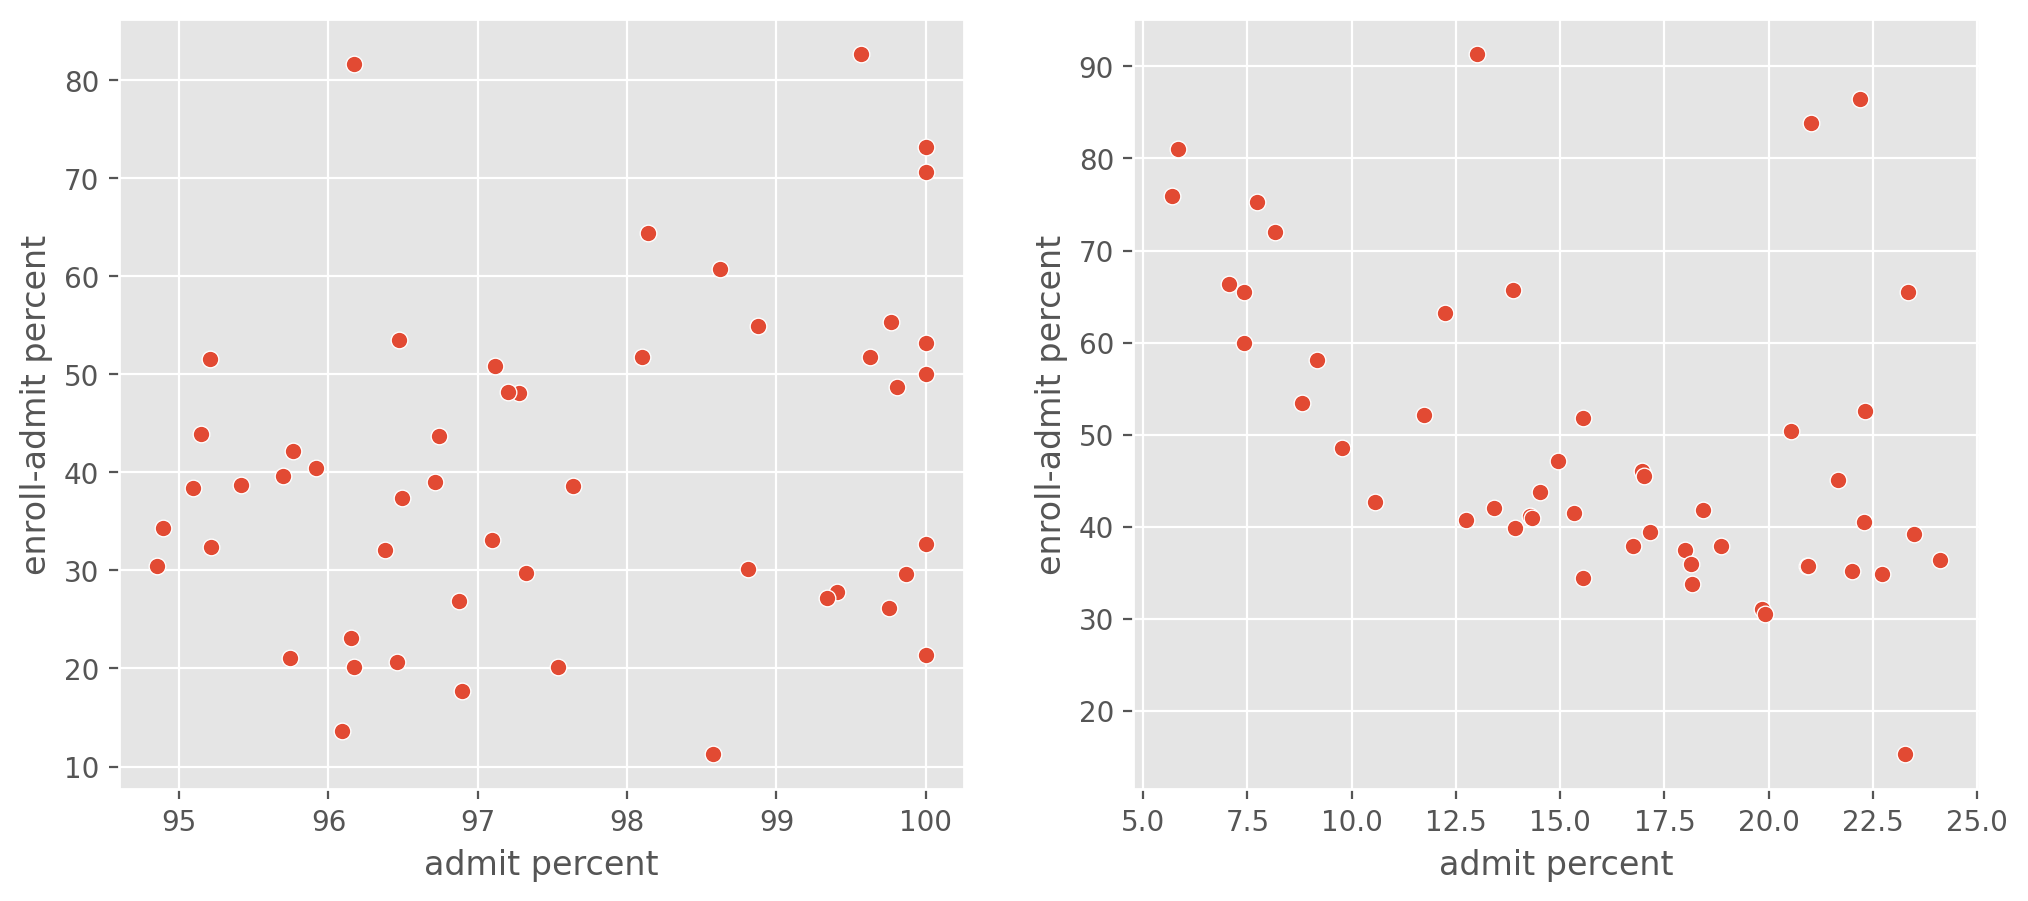

In [26]:
plt.figure(figsize=(12,5),dpi=200)
plt.subplot(1,2,1)
sns.scatterplot("admit percent","enroll-admit percent",data=sorted_enroll_high)

plt.subplot(1,2,2)
sns.scatterplot("admit percent","enroll-admit percent",data=sorted_enroll_low)

In [27]:
sorted_enroll_low["enroll-admit percent"].mean()

49.36628194806439

In [28]:
sorted_enroll_high["enroll-admit percent"].mean()

40.29174790107945

#### 
 - Here we analysed that the percentage of total students who got admission to a university with respect to the number of applications and total students who actually enrolled  has very weak corelation. 
 - If we consider the top 50  universities and bottom 50 universities based on the percentage of  admission they have offered to the students ,we can see that universities which has selected  less than 25% of students from total applicants have more percentage of students enrolled with them than the universities which had admitted more than the 95% of the total applicants.
 - So based on the analysis we can say that higher rate of admission is the not the main reason for the students for preferring a particular university

In [29]:
university[["Name","Control of institution"]]

,Name,Control of institution
0,Alabama A & M University,Public
1,University of Alabama at Birmingham,Public
2,Amridge University,Private not-for-profit
3,University of Alabama in Huntsville,Public
4,Alabama State University,Public
...,...,...
1529,University of South Florida-Sarasota-Manatee,Public
1530,The Kingâ€™s College,Private not-for-profit
1531,Ottawa University-Online,Private not-for-profit
1532,Providence Christian College,Private not-for-profit


In [96]:
uni_control=university["Control of institution"].value_counts()
uni_control

Private not-for-profit    971
Public                    563
Name: Control of institution, dtype: int64

In [97]:
enroll_control=university[["Control of institution","Enrolled total"]].groupby("Control of institution")["Enrolled total"].sum()
enroll_control

Control of institution
Private not-for-profit    467960.0
Public                    968315.0
Name: Enrolled total, dtype: float64

In [98]:
app_control=university[["Control of institution","Applicants total"]].groupby("Control of institution")["Applicants total"].sum()
app_control

Control of institution
Private not-for-profit    3932271.0
Public                    4868402.0
Name: Applicants total, dtype: float64

Text(0, 0.5, 'No.of enrollment')

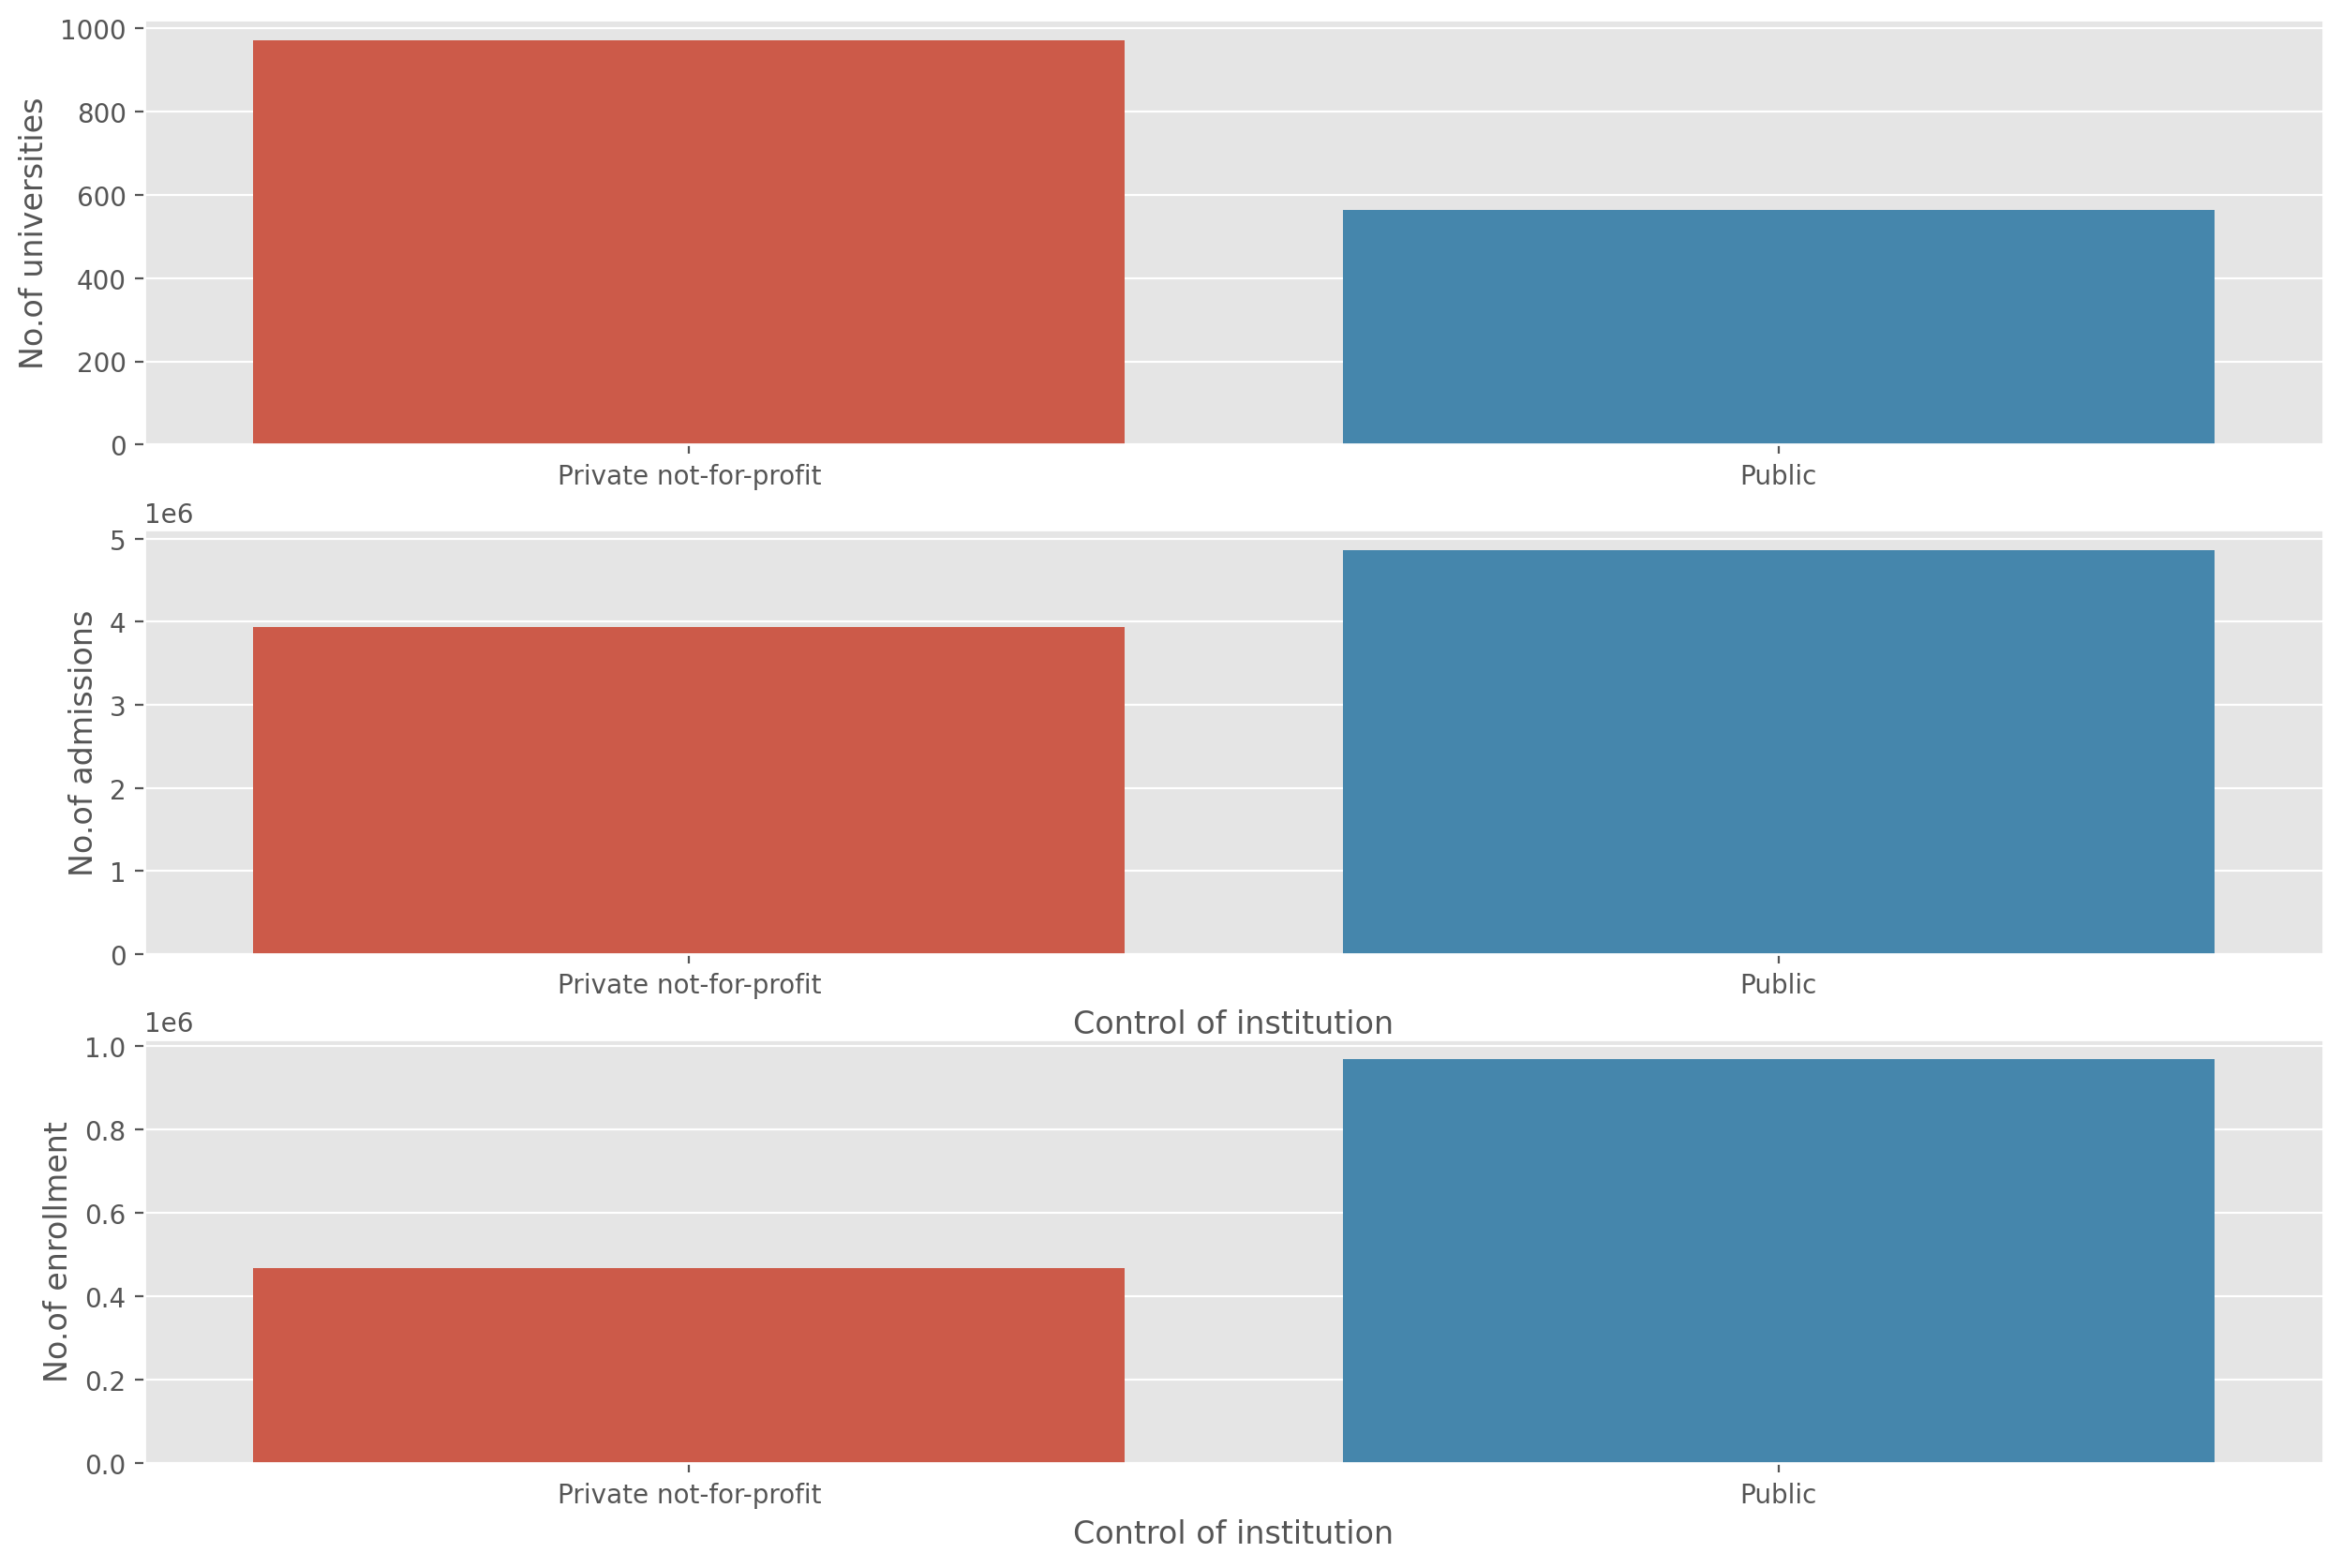

In [33]:
plt.figure(figsize=(15,10),dpi=200)
plt.subplot(3,1,1)
sns.barplot(uni_control.index,uni_control.values)
plt.ylabel("No.of universities")

plt.subplot(3,1,2)
sns.barplot(app_control.index,app_control.values)
plt.ylabel("No.of admissions")

plt.subplot(3,1,3)
sns.barplot(enroll_control.index,enroll_control.values)
plt.ylabel("No.of enrollment")


 - Eventhough no.of universities in Private(not-for-profit) sector is more than Public sector ,most students had applied for admission in the public sectors.
 - And even the students prefered to enroll in Public universities than Private ones when they received the admission.

In [34]:
fees=university[["Name","Enrolled total","Tuition and fees, 2013-14"]]
fees

,Name,Enrolled total,"Tuition and fees, 2013-14"
0,Alabama A & M University,1104.0,7182.0
1,University of Alabama at Birmingham,1773.0,7206.0
2,Amridge University,NaN,6870.0
3,University of Alabama in Huntsville,651.0,9192.0
4,Alabama State University,1479.0,8720.0
...,...,...,...
1529,University of South Florida-Sarasota-Manatee,86.0,5587.0
1530,The Kingâ€™s College,127.0,31300.0
1531,Ottawa University-Online,NaN,NaN
1532,Providence Christian College,20.0,24222.0


In [35]:
fees.isnull().sum()

Name                           0
Enrolled total               157
Tuition and fees, 2013-14     37
dtype: int64

In [36]:
avg_fees=fees["Tuition and fees, 2013-14"].mean()
avg_fees

20727.490313961254

In [37]:
fees['Tuition and fees, 2013-14'].fillna((fees['Tuition and fees, 2013-14'].mean()),inplace=True)
fees

,Name,Enrolled total,"Tuition and fees, 2013-14"
0,Alabama A & M University,1104.0,7182.000000
1,University of Alabama at Birmingham,1773.0,7206.000000
2,Amridge University,NaN,6870.000000
3,University of Alabama in Huntsville,651.0,9192.000000
4,Alabama State University,1479.0,8720.000000
...,...,...,...
1529,University of South Florida-Sarasota-Manatee,86.0,5587.000000
1530,The Kingâ€™s College,127.0,31300.000000
1531,Ottawa University-Online,NaN,20727.490314
1532,Providence Christian College,20.0,24222.000000


In [38]:
fees.describe()

,Enrolled total,"Tuition and fees, 2013-14"
count,1377.000000,1534.000000
mean,1043.046478,20727.490314
std,1285.165519,12304.572583
min,0.000000,1032.000000
25%,287.000000,8707.000000
50%,538.000000,20710.000000
75%,1246.000000,29807.500000
max,10241.000000,49138.000000


In [39]:
fees[["Enrolled total","Tuition and fees, 2013-14"]].corr()

,Enrolled total,"Tuition and fees, 2013-14"
Enrolled total,1.000000,-0.321142
"Tuition and fees, 2013-14",-0.321142,1.000000


<AxesSubplot:>

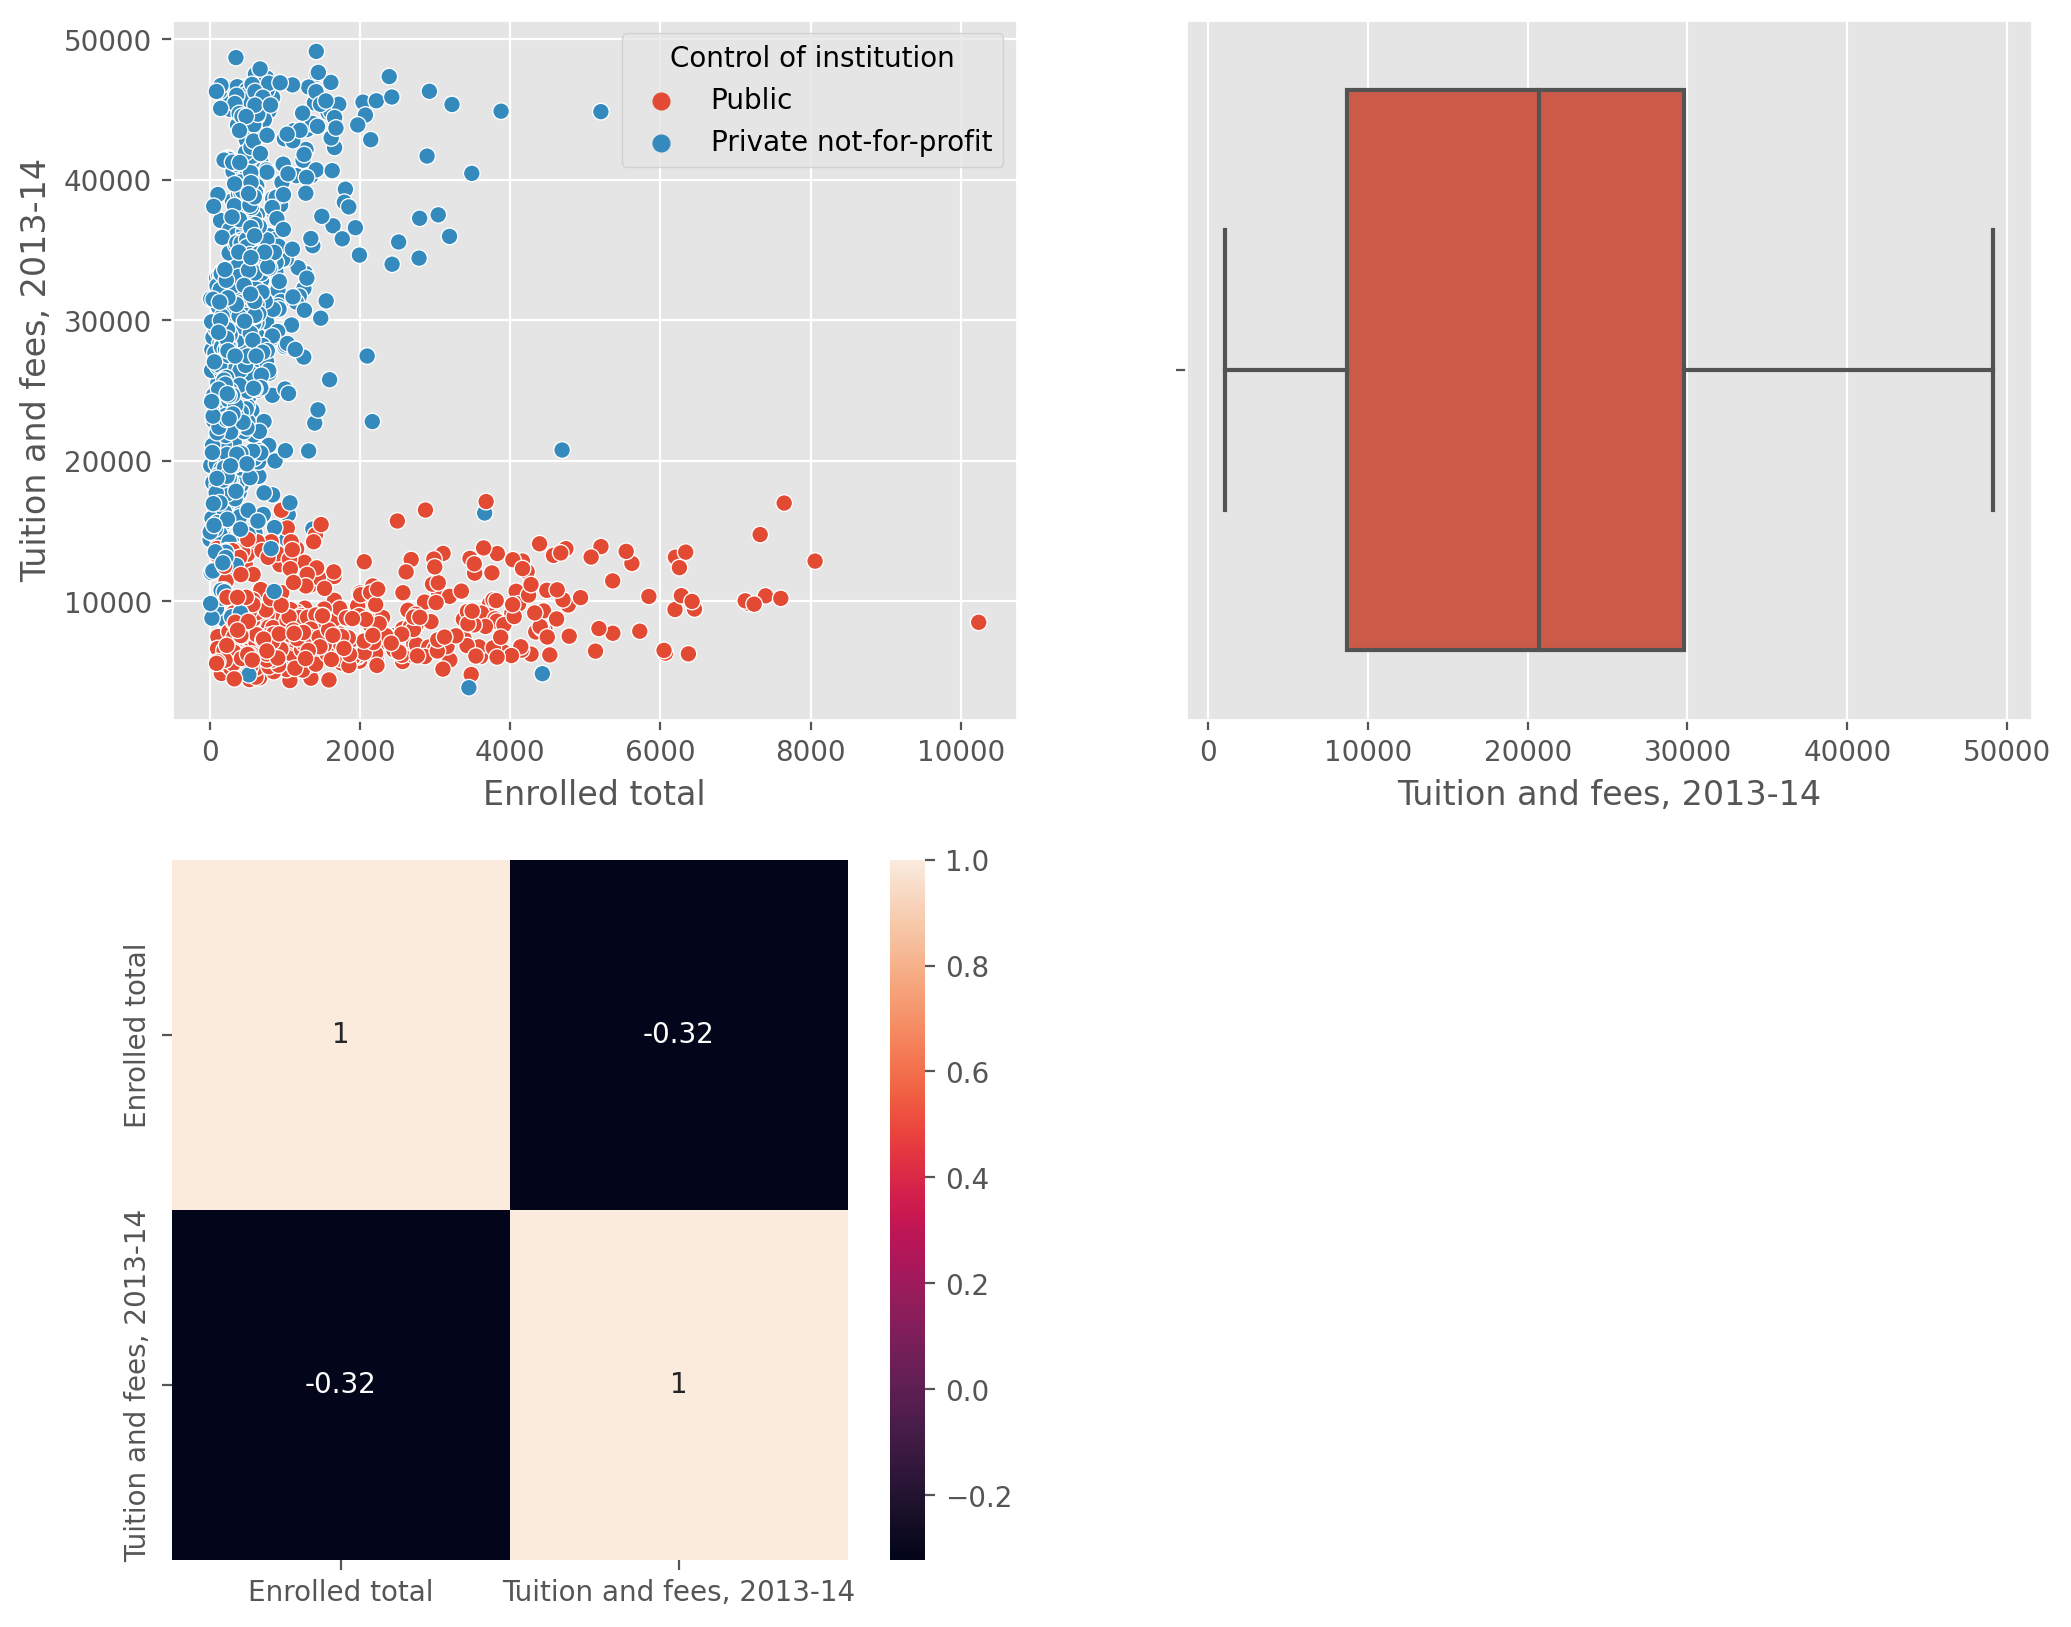

In [40]:
plt.figure(figsize=(12,10),dpi=200)
plt.subplot(2,2,1)
sns.scatterplot("Enrolled total","Tuition and fees, 2013-14",hue=university["Control of institution"],data=fees)

plt.subplot(2,2,2)
sns.boxplot(fees["Tuition and fees, 2013-14"])

plt.subplot(2,2,3)
sns.heatmap(fees[["Enrolled total","Tuition and fees, 2013-14"]].corr(),annot=True)

In [99]:
x=fees["Enrolled total"][fees["Tuition and fees, 2013-14"]<avg_fees].sum()
x

1025323.0

In [100]:
y=fees["Enrolled total"].sum()
y

1436275.0

In [101]:
x/y*100

71.38765208612557

In [102]:
university["Control of institution"].value_counts()

Private not-for-profit    971
Public                    563
Name: Control of institution, dtype: int64

In [45]:
university["Control of institution"][fees["Tuition and fees, 2013-14"]<avg_fees].groupby(university["Control of institution"]).count()

Control of institution
Private not-for-profit    214
Public                    555
Name: Control of institution, dtype: int64

In [94]:
214/971*100
avg_private

22.039134912461382

- The tution fees for the year 2013-2014 ranges from 1000 to 50000.

- The total students enrolled in the universities and their tution fees has a moderate negative corelation of -0.32.

- overall we can see that the more than 70% of the students who had enrolled in the year 2013 has selected the universities which has less than the average tution fees along the country.

- All the universities which comes under the Public sector and only 25% of universities under Private sector has less than the average fees.

In [47]:
accomodation=university[["Name","Enrolled total","Total price for in-state students living on campus 2013-14","Total price for out-of-state students living on campus 2013-14"]]
accomodation

,Name,Enrolled total,Total price for in-state students living on campus 2013-14,Total price for out-of-state students living on campus 2013-14
0,Alabama A & M University,1104.0,21849.0,27441.0
1,University of Alabama at Birmingham,1773.0,22495.0,31687.0
2,Amridge University,NaN,NaN,NaN
3,University of Alabama in Huntsville,651.0,23466.0,35780.0
4,Alabama State University,1479.0,18286.0,25222.0
...,...,...,...,...
1529,University of South Florida-Sarasota-Manatee,86.0,NaN,NaN
1530,The Kingâ€™s College,127.0,48717.0,48717.0
1531,Ottawa University-Online,NaN,NaN,NaN
1532,Providence Christian College,20.0,38602.0,38602.0


In [48]:
accomodation.isnull().sum()

Name                                                                0
Enrolled total                                                    157
Total price for in-state students living on campus 2013-14        134
Total price for out-of-state students living on campus 2013-14    134
dtype: int64

In [49]:
accomodation.describe()

,Enrolled total,Total price for in-state students living on campus 2013-14,Total price for out-of-state students living on campus 2013-14
count,1377.000000,1400.000000,1400.000000
mean,1043.046478,34935.306429,38767.612857
std,1285.165519,13283.049319,10716.524007
min,0.000000,9768.000000,9768.000000
25%,287.000000,22487.000000,31128.000000
50%,538.000000,34115.000000,37193.500000
75%,1246.000000,44835.750000,45907.500000
max,10241.000000,64988.000000,64988.000000


In [50]:
accomodation["Total price for in-state students living on campus 2013-14"]=accomodation["Total price for in-state students living on campus 2013-14"].fillna(accomodation["Total price for in-state students living on campus 2013-14"].mean())
accomodation["Total price for out-of-state students living on campus 2013-14"]=accomodation["Total price for out-of-state students living on campus 2013-14"].fillna(accomodation["Total price for out-of-state students living on campus 2013-14"].mean())

In [51]:
accomodation

,Name,Enrolled total,Total price for in-state students living on campus 2013-14,Total price for out-of-state students living on campus 2013-14
0,Alabama A & M University,1104.0,21849.000000,27441.000000
1,University of Alabama at Birmingham,1773.0,22495.000000,31687.000000
2,Amridge University,NaN,34935.306429,38767.612857
3,University of Alabama in Huntsville,651.0,23466.000000,35780.000000
4,Alabama State University,1479.0,18286.000000,25222.000000
...,...,...,...,...
1529,University of South Florida-Sarasota-Manatee,86.0,34935.306429,38767.612857
1530,The Kingâ€™s College,127.0,48717.000000,48717.000000
1531,Ottawa University-Online,NaN,34935.306429,38767.612857
1532,Providence Christian College,20.0,38602.000000,38602.000000


<AxesSubplot:xlabel='Total price for out-of-state students living on campus 2013-14'>

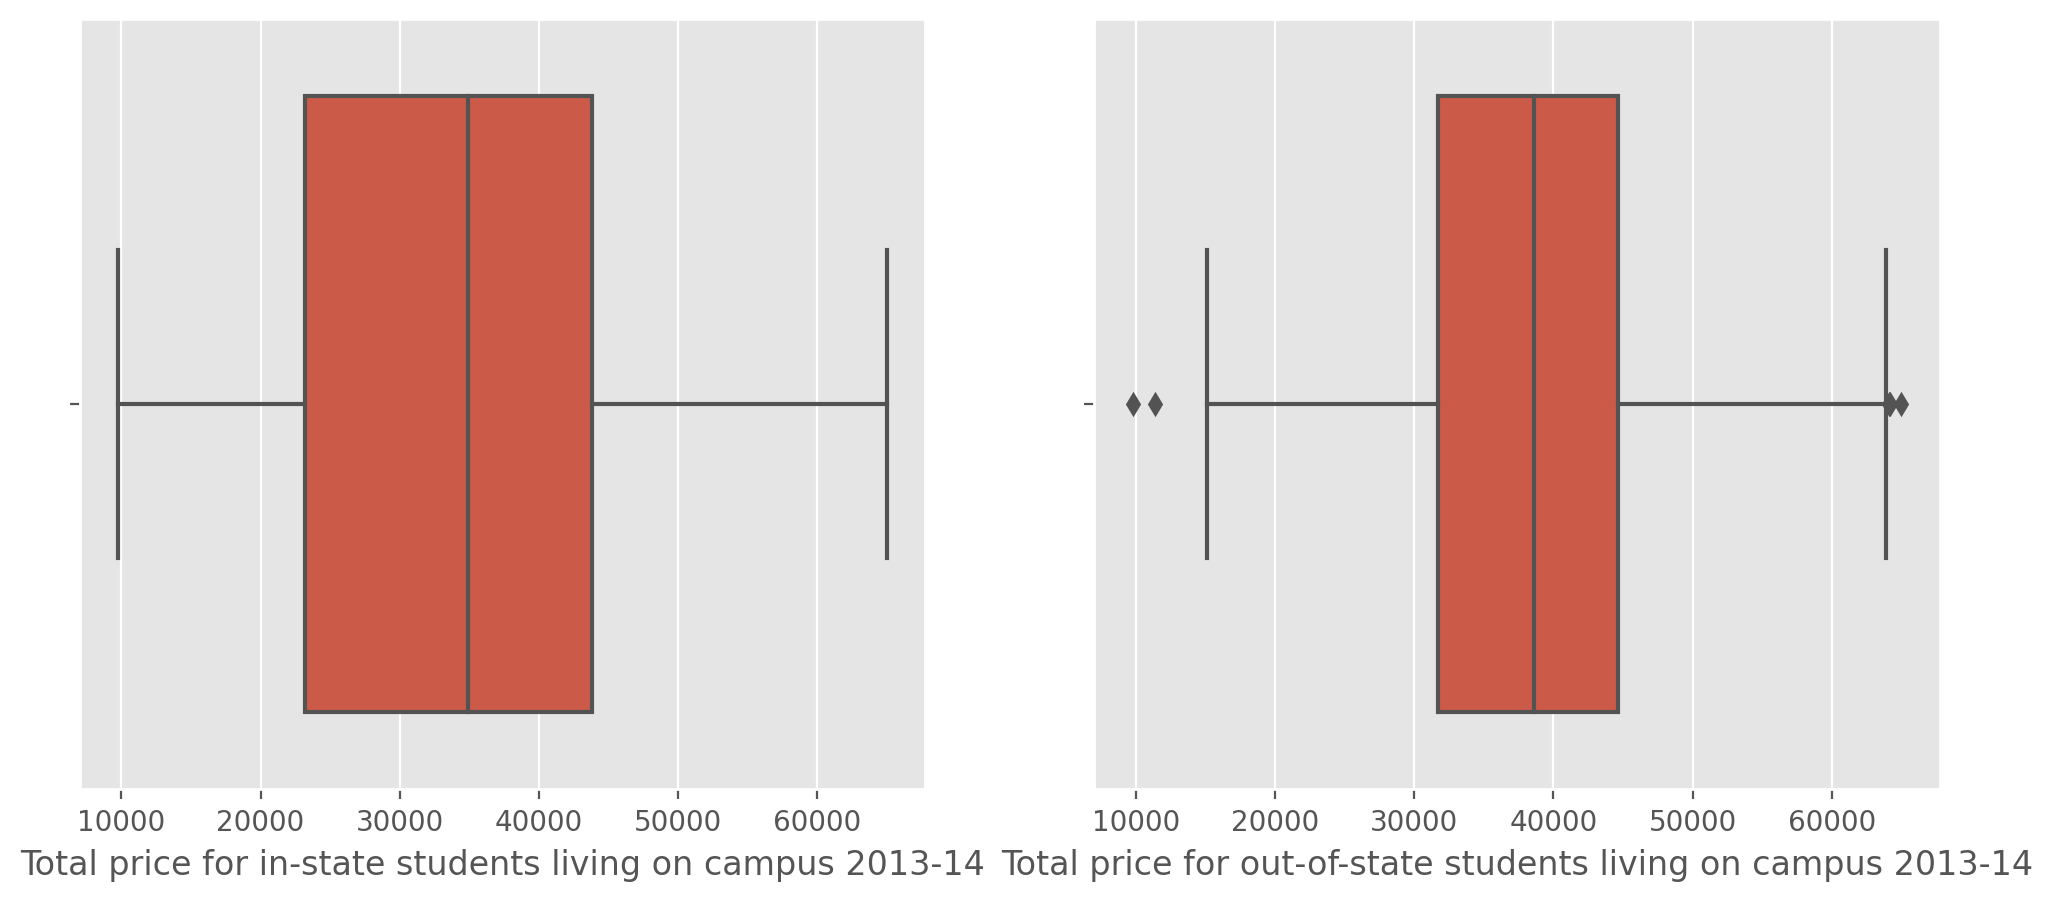

In [52]:
plt.figure(figsize=(12,5),dpi=200)
plt.subplot(1,2,1)
sns.boxplot(accomodation["Total price for in-state students living on campus 2013-14"])

plt.subplot(1,2,2)
sns.boxplot(accomodation["Total price for out-of-state students living on campus 2013-14"])

In [53]:
in_state=accomodation[["Enrolled total","Total price for in-state students living on campus 2013-14"]]
in_state.corr()

,Enrolled total,Total price for in-state students living on campus 2013-14
Enrolled total,1.000000,-0.283509
Total price for in-state students living on campus 2013-14,-0.283509,1.000000


In [54]:
out_state=accomodation[["Enrolled total","Total price for out-of-state students living on campus 2013-14"]]
out_state.corr()

,Enrolled total,Total price for out-of-state students living on campus 2013-14
Enrolled total,1.000000,0.009606
Total price for out-of-state students living on campus 2013-14,0.009606,1.000000


<AxesSubplot:>

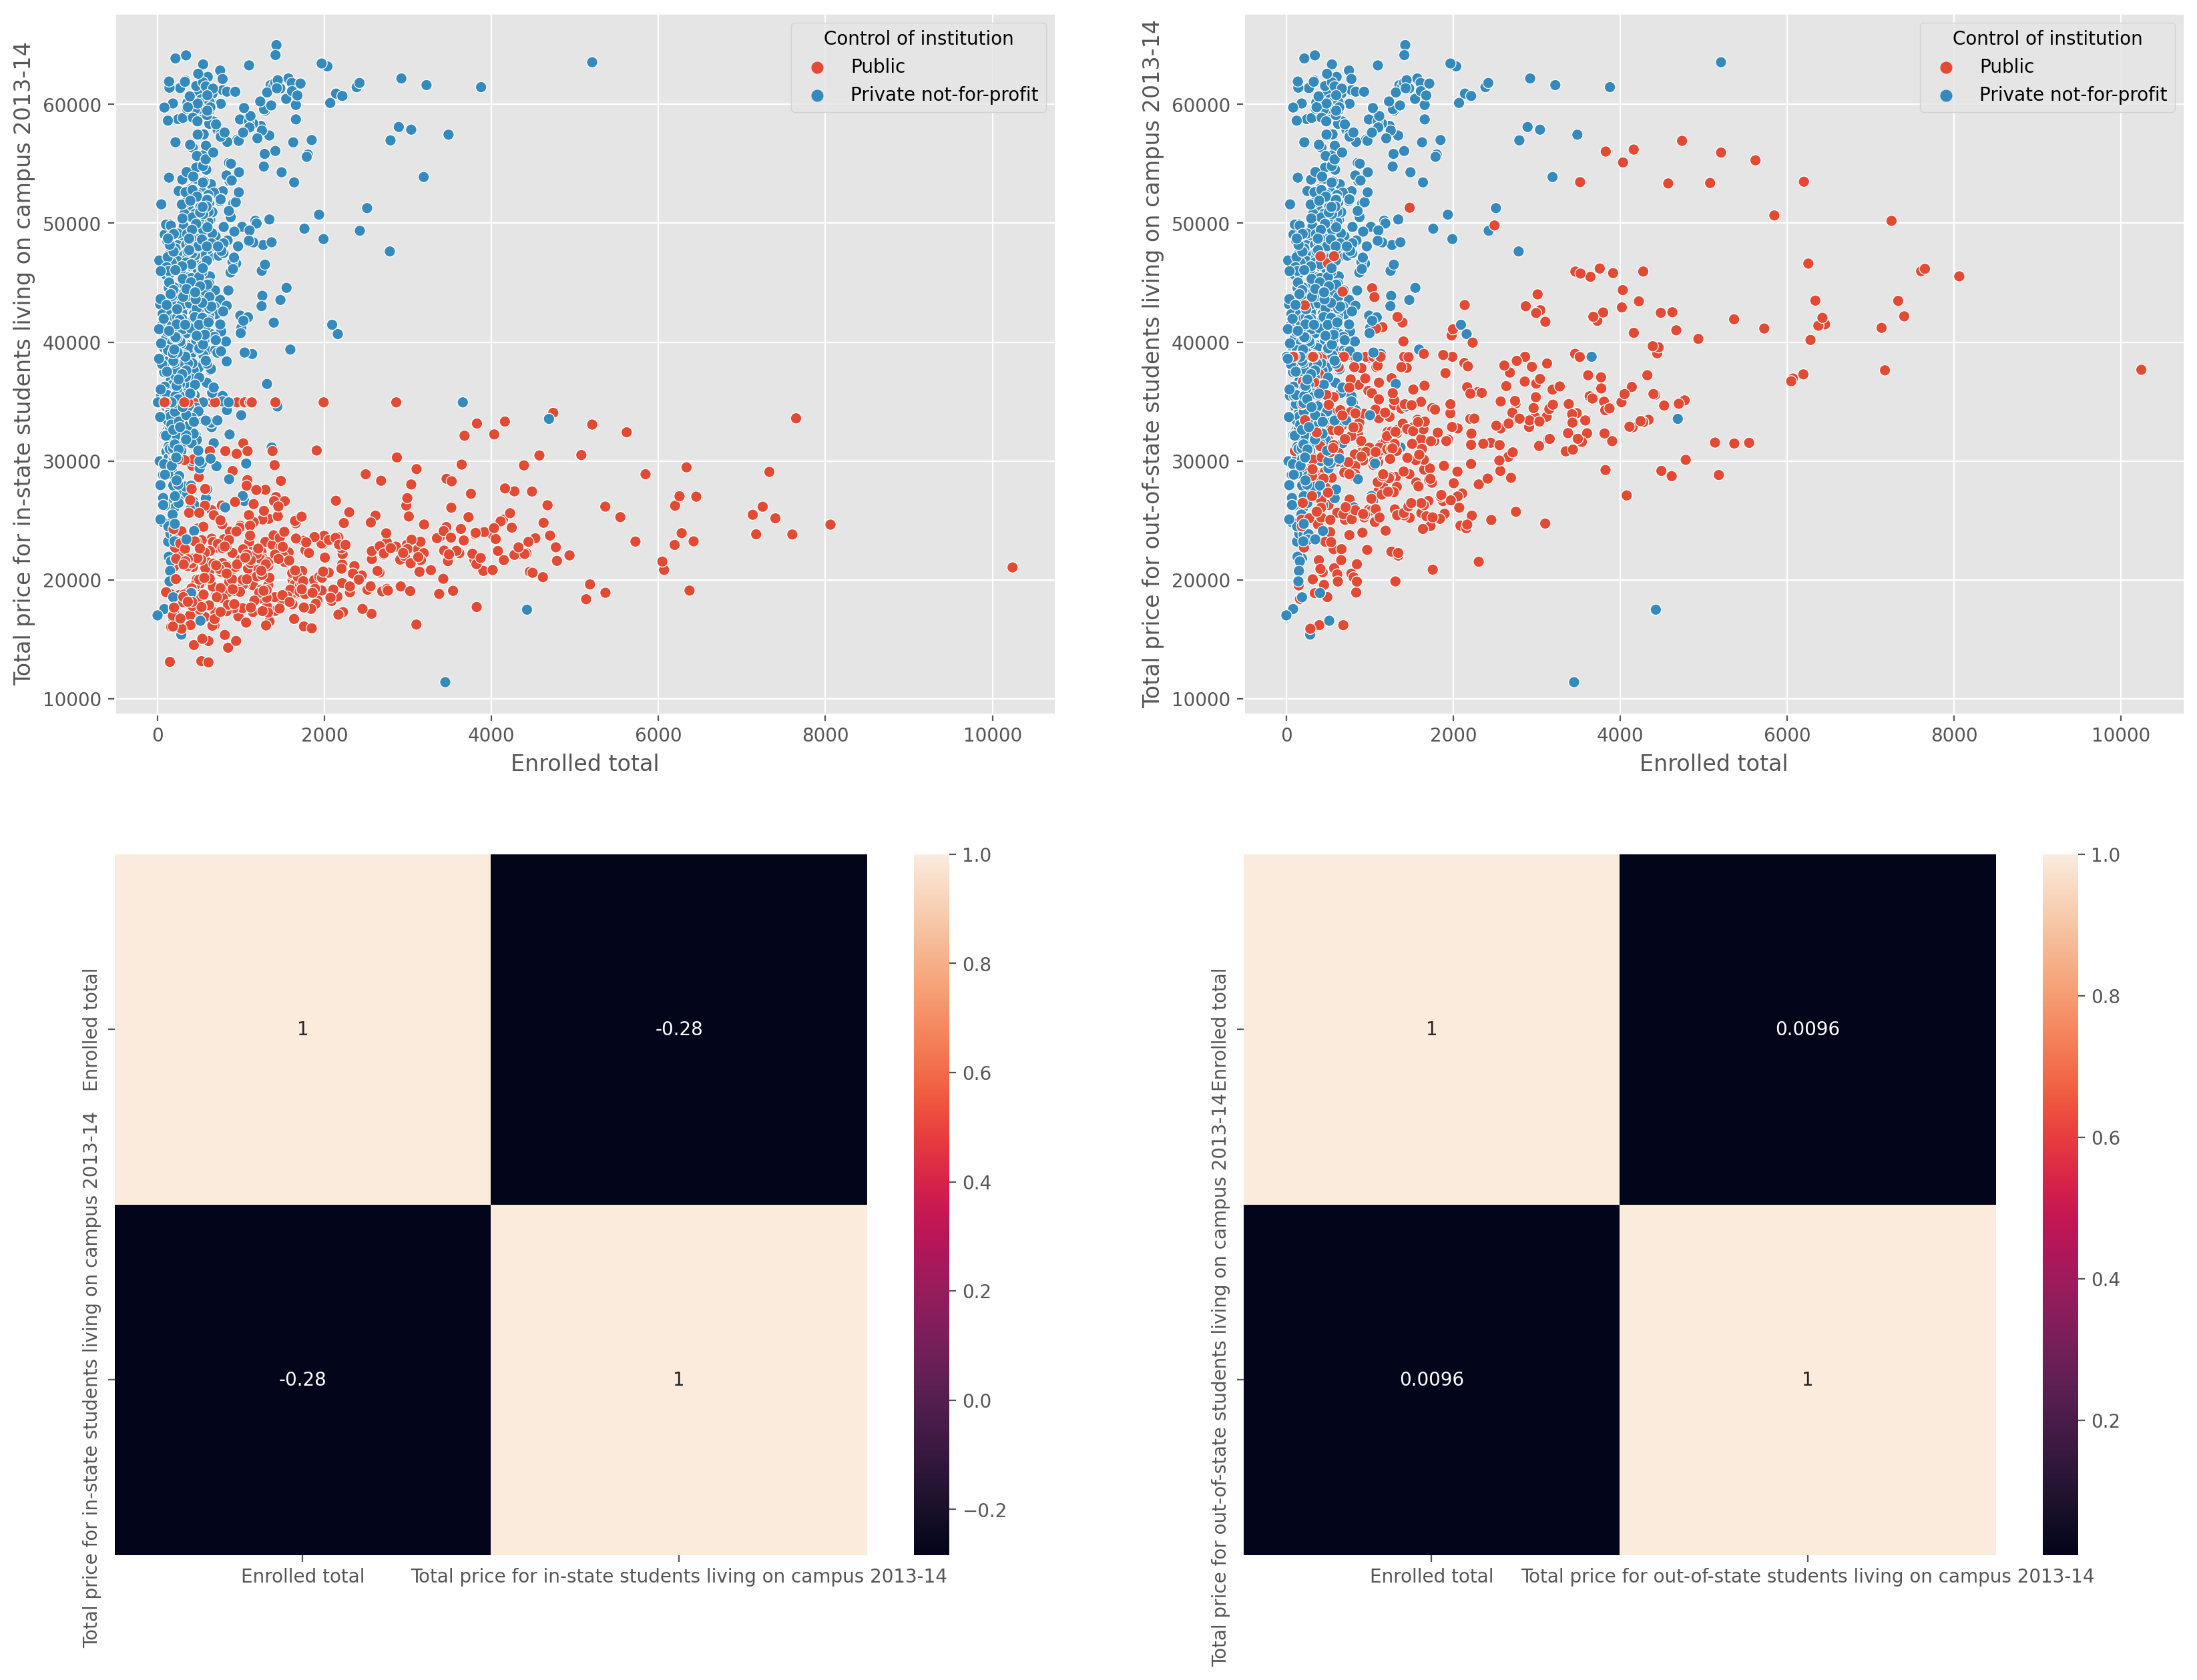

In [55]:
plt.figure(figsize=(20,15),dpi=200)

plt.subplot(2,2,1)
sns.scatterplot("Enrolled total","Total price for in-state students living on campus 2013-14",hue=university["Control of institution"],data=accomodation)

plt.subplot(2,2,2)
sns.scatterplot("Enrolled total","Total price for out-of-state students living on campus 2013-14",hue=university["Control of institution"],data=accomodation)

plt.subplot(2,2,3)
sns.heatmap(in_state.corr(),annot=True)

plt.subplot(2,2,4)
sns.heatmap(out_state.corr(),annot=True)


In [56]:
in_state_mean=university["Total price for in-state students living on campus 2013-14"].mean()
out_state_mean=university["Total price for out-of-state students living on campus 2013-14"].mean()

In [57]:
a=accomodation["Enrolled total"][accomodation["Total price for in-state students living on campus 2013-14"]<in_state_mean].sum()
a

1017443.0

In [58]:
b=accomodation["Enrolled total"][accomodation["Total price for out-of-state students living on campus 2013-14"]<out_state_mean].sum()
b

769252.0

In [59]:
c=accomodation["Enrolled total"].sum()
c

1436275.0

In [60]:
print("Percentage of Enrolled in-state students who pays less than average accomodation cost : ",a/c*100)

Percentage of Enrolled in-state students who pays less than average accomodation cost :  70.83901063514996


In [61]:
print("Percentage of Enrolled out-of-state students who pays less than average accomodation cost : ",b/c*100)

Percentage of Enrolled out-of-state students who pays less than average accomodation cost :  53.55882404135698


- Among the in-state students who prefered to chose living on campus in the year 2013-2014, 70.83 % of them choose the universities with less than average accomodation cost.
- and among the out-of-state students who prefered to chose living on campus in the year 2013-2014, 53.55% of them choose the universities with less than average accomodation cost.


In [62]:
states_gdp =pd.read_csv("states_gdp.csv")

In [63]:
states_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   code         51 non-null     int64  
 1   state        51 non-null     object 
 2   gdp_million  51 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.3+ KB


In [64]:
states_gdp.duplicated().sum()

0

In [65]:
states_gdp.isnull().sum()

code           0
state          0
gdp_million    0
dtype: int64

In [66]:
states=university.groupby("State abbreviation")["Applicants total","Enrolled total"].sum().sort_index()
states

,Applicants total,Enrolled total
State abbreviation,,
Alabama,122489.0,26226.0
Alaska,494.0,33.0
Arizona,84520.0,19931.0
Arkansas,57196.0,16609.0
California,1188841.0,120777.0
Colorado,117825.0,26057.0
Connecticut,169126.0,18529.0
Delaware,37275.0,5816.0
District of Columbia,79414.0,8292.0


In [67]:
states.index=range(0,51)
states

,Applicants total,Enrolled total
0,122489.0,26226.0
1,494.0,33.0
2,84520.0,19931.0
3,57196.0,16609.0
4,1188841.0,120777.0
5,117825.0,26057.0
6,169126.0,18529.0
7,37275.0,5816.0
8,79414.0,8292.0
9,343072.0,56893.0


In [68]:
enroll_gdp=pd.concat([states_gdp,states],axis=1)
enroll_gdp.head()

,code,state,gdp_million,Applicants total,Enrolled total
0,1000,Alabama,191481.0,122489.0,26226.0
1,2000,Alaska,56622.8,494.0,33.0
2,4000,Arizona,275199.1,84520.0,19931.0
3,5000,Arkansas,114251.5,57196.0,16609.0
4,6000,California,2262771.2,1188841.0,120777.0


In [69]:
enroll_gdp.sort_values(by="gdp_million",ascending=False).head()

,code,state,gdp_million,Applicants total,Enrolled total
4,6000,California,2262771.2,1188841.0,120777.0
43,48000,Texas,1502249.8,446691.0,93767.0
32,36000,New York,1355581.4,1024210.0,111033.0
9,12000,Florida,800704.1,343072.0,56893.0
13,17000,Illinois,739627.9,344835.0,50238.0


In [70]:
enroll_gdp.describe()

,code,gdp_million,Applicants total,Enrolled total
count,51.000000,5.100000e+01,5.100000e+01,51.000000
mean,28960.784314,3.268928e+05,1.725622e+05,28162.254902
std,15832.827649,4.088304e+05,2.291227e+05,27043.783602
min,1000.000000,2.909880e+04,4.940000e+02,33.000000
25%,16500.000000,8.209975e+04,4.510900e+04,8740.500000
50%,29000.000000,1.830149e+05,1.035770e+05,19524.000000
75%,41500.000000,4.260313e+05,1.892565e+05,36132.000000
max,56000.000000,2.262771e+06,1.188841e+06,120777.000000


In [71]:
enroll_gdp[["gdp_million","Enrolled total"]].corr()

,gdp_million,Enrolled total
gdp_million,1.000000,0.929593
Enrolled total,0.929593,1.000000


In [72]:
enroll_gdp[["gdp_million","Applicants total"]].corr()

,gdp_million,Applicants total
gdp_million,1.000000,0.926486
Applicants total,0.926486,1.000000


<AxesSubplot:>

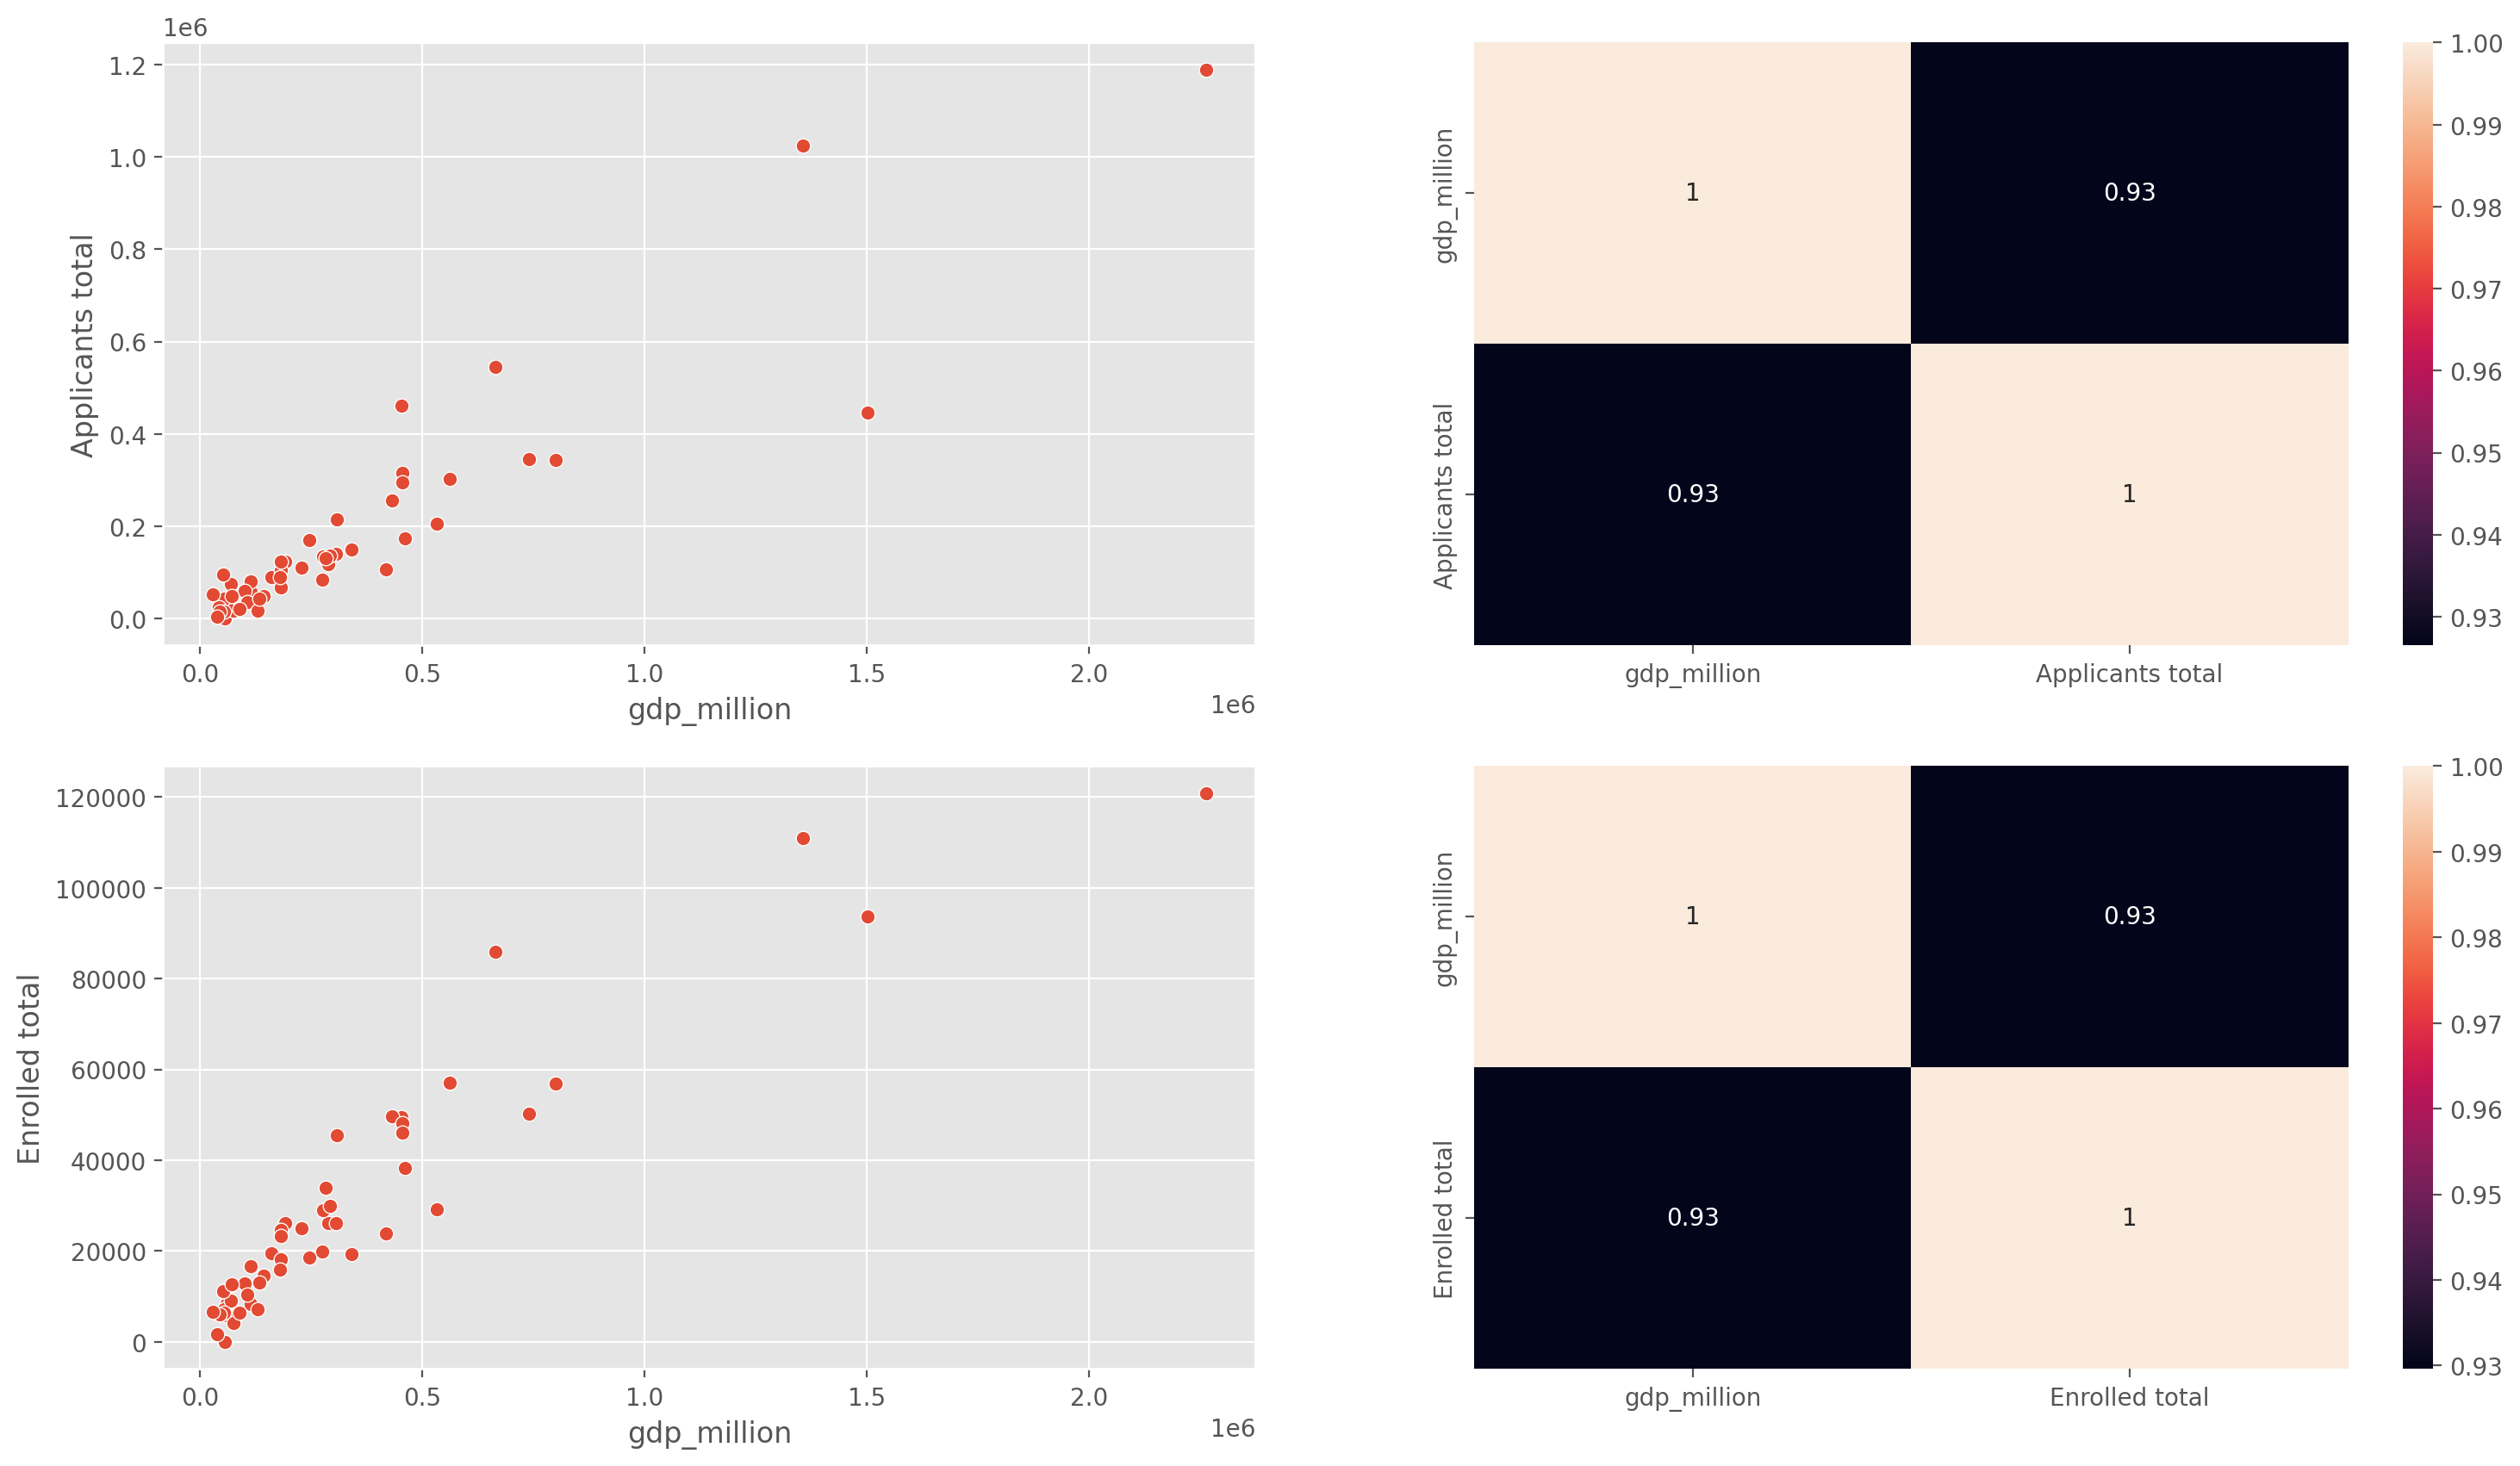

In [73]:
plt.figure(figsize=(18,10),dpi=200)

plt.subplot(2,2,1)
sns.scatterplot("gdp_million","Applicants total",data=enroll_gdp)

plt.subplot(2,2,2)
sns.heatmap(enroll_gdp[["gdp_million","Applicants total"]].corr(),annot=True)

plt.subplot(2,2,3)
sns.scatterplot("gdp_million","Enrolled total",data=enroll_gdp)

plt.subplot(2,2,4)
sns.heatmap(enroll_gdp[["gdp_million","Enrolled total"]].corr(),annot=True)

- Here the total number of applicants in a particluar state and the gdp of that state has a high correlation of .93
  and the total no.of enrolled students in a state and the gdp of that state also has a high correlation of .93

In [74]:
higher_stud=university[["Name","Enrolled total","Highest degree offered"]]
higher_stud

,Name,Enrolled total,Highest degree offered
0,Alabama A & M University,1104.0,Doctor's degree - research/scholarship
1,University of Alabama at Birmingham,1773.0,Doctor's degree - research/scholarship and pro...
2,Amridge University,NaN,Doctor's degree - research/scholarship and pro...
3,University of Alabama in Huntsville,651.0,Doctor's degree - research/scholarship and pro...
4,Alabama State University,1479.0,Doctor's degree - research/scholarship and pro...
...,...,...,...
1529,University of South Florida-Sarasota-Manatee,86.0,Master's degree
1530,The Kingâ€™s College,127.0,Bachelor's degree
1531,Ottawa University-Online,NaN,Master's degree
1532,Providence Christian College,20.0,Bachelor's degree


In [75]:
higher_stud.isnull().sum()

Name                        0
Enrolled total            157
Highest degree offered      0
dtype: int64

In [76]:
mean1=int(higher_stud["Enrolled total"].mean())
mean1

1043

In [77]:
higher_stud["Enrolled total"]=higher_stud["Enrolled total"].fillna(mean1)

In [78]:
for i in higher_stud["Enrolled total"]:
    print(i)
    

1104.0
1773.0
1043.0
651.0
1479.0
6454.0
1043.0
579.0
3726.0
356.0
1043.0
1043.0
261.0
1158.0
68.0
380.0
1043.0
259.0
531.0
970.0
409.0
765.0
1878.0
431.0
257.0
1043.0
2087.0
650.0
1043.0
1043.0
1043.0
33.0
1043.0
7171.0
7401.0
448.0
4772.0
1043.0
49.0
90.0
667.0
1043.0
174.0
4339.0
568.0
1619.0
1755.0
1043.0
2157.0
129.0
1041.0
704.0
436.0
305.0
394.0
159.0
1043.0
156.0
663.0
1343.0
1250.0
903.0
1043.0
993.0
249.0
540.0
3635.0
28.0
1328.0
1109.0
2448.0
3120.0
2714.0
1214.0
3139.0
4526.0
1572.0
4276.0
2908.0
4149.0
3151.0
4162.0
5208.0
5077.0
5620.0
4034.0
4575.0
4741.0
3827.0
198.0
1289.0
373.0
99.0
1043.0
337.0
60.0
305.0
1043.0
212.0
0.0
217.0
87.0
1237.0
1043.0
1043.0
23.0
623.0
1043.0
477.0
209.0
1341.0
139.0
217.0
1043.0
559.0
1043.0
172.0
548.0
78.0
335.0
958.0
784.0
261.0
647.0
397.0
673.0
4139.0
1238.0
3807.0
1148.0
3384.0
1278.0
272.0
150.0
622.0
1749.0
392.0
2922.0
88.0
298.0
446.0
118.0
519.0
991.0
1616.0
5846.0
447.0
522.0
949.0
4443.0
1043.0
1413.0
876.0
2214.0
1991.0
38.

In [79]:
higher_stud.isnull().sum()

Name                      0
Enrolled total            0
Highest degree offered    0
dtype: int64

In [80]:
higher_stud["Highest degree offered"].value_counts()

Master's degree                                                     587
Doctor's degree - research/scholarship and professional practice    311
Bachelor's degree                                                   282
Doctor's degree - research/scholarship                              201
Doctor's degree - professional practice                             125
Doctor's degree - other                                              28
Name: Highest degree offered, dtype: int64

In [81]:
high_enroll=higher_stud[["Highest degree offered","Enrolled total"]].groupby("Highest degree offered")["Enrolled total"].sum()
high_enroll

Highest degree offered
Bachelor's degree                                                   144488.0
Doctor's degree - other                                              36158.0
Doctor's degree - professional practice                             103803.0
Doctor's degree - research/scholarship                              225515.0
Doctor's degree - research/scholarship and professional practice    732743.0
Master's degree                                                     357319.0
Name: Enrolled total, dtype: float64

<AxesSubplot:ylabel='Highest degree offered'>

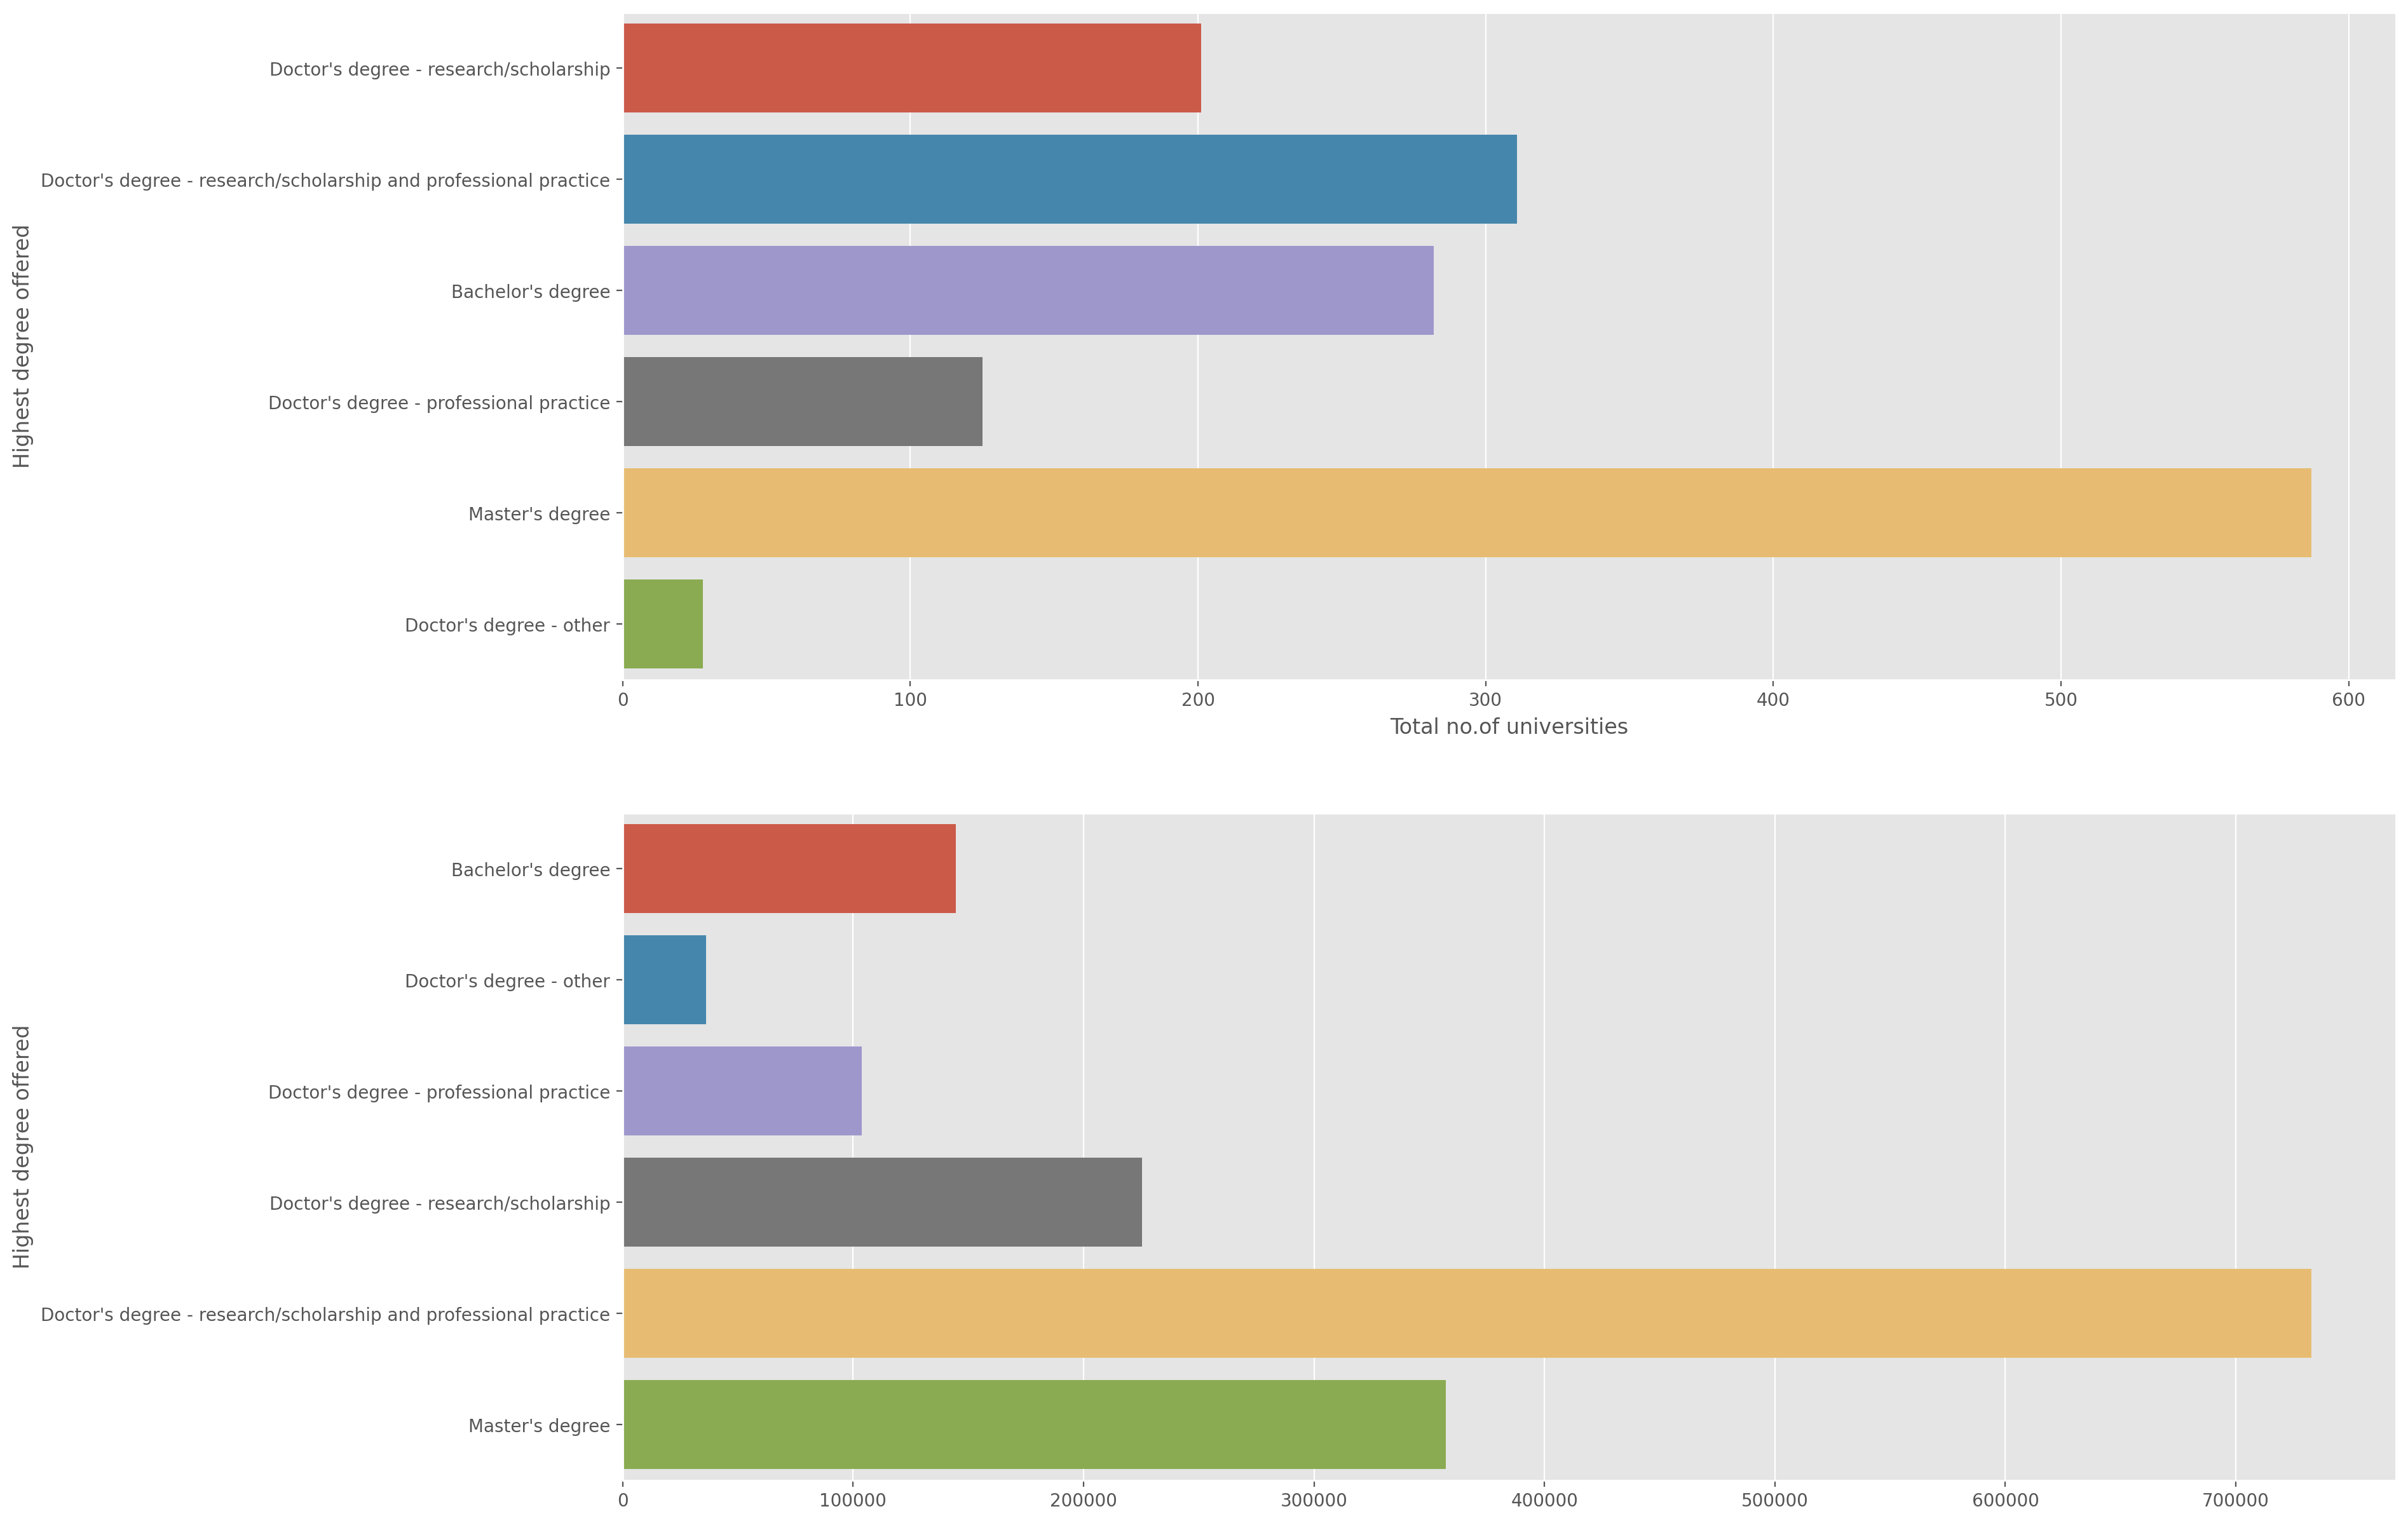

In [82]:
plt.figure(figsize=(18,15),dpi=200)
plt.subplot(2,1,1)
sns.countplot(y=higher_stud["Highest degree offered"])
plt.xlabel("Total no.of universities")

plt.subplot(2,1,2)
sns.barplot(high_enroll.values,high_enroll.index)

In [83]:
total=higher_stud["Enrolled total"].sum()
total

1600026.0

In [84]:
enroll_highuni=higher_stud[higher_stud["Highest degree offered"]!="Bachelor's degree"]["Enrolled total"].sum()
enroll_highuni

1455538.0

In [85]:
percent=(enroll_highuni/total)*100
print("The percentage of students enrolled in universities offering higher degree",percent)

The percentage of students enrolled in universities offering higher degree 90.96964674324042


In [86]:
a=higher_stud["Highest degree offered"].value_counts()
a

Master's degree                                                     587
Doctor's degree - research/scholarship and professional practice    311
Bachelor's degree                                                   282
Doctor's degree - research/scholarship                              201
Doctor's degree - professional practice                             125
Doctor's degree - other                                              28
Name: Highest degree offered, dtype: int64

In [87]:
b=higher_stud[higher_stud["Highest degree offered"]!="Bachelor's degree"]["Highest degree offered"].value_counts()
b

Master's degree                                                     587
Doctor's degree - research/scholarship and professional practice    311
Doctor's degree - research/scholarship                              201
Doctor's degree - professional practice                             125
Doctor's degree - other                                              28
Name: Highest degree offered, dtype: int64

In [88]:
print("Percentage of university which provides higher degree : ",(b.sum()/a.sum())*100)

Percentage of university which provides higher degree :  81.61668839634942


- 90.96 % of total students chose universities that provides a higher degree than bachelors degree
- Around 82% of the universities in America provides a higher degree

In [89]:
print("Likely enrollment rate : ",uni["enroll percent"].mean())

Likely enrollment rate :  21.14764522497168


In [90]:
print("Likely graduation rate in 4 years Bachelors: ",university["Graduation rate - Bachelor degree within 4 years, total"].mean())

Likely graduation rate in 4 years Bachelors:  37.450542005420054


In [91]:
print("Likely graduation rate in 5 years Bachelors : ",university["Graduation rate - Bachelor degree within 5 years, total"].mean())

Likely graduation rate in 5 years Bachelors :  49.78861788617886


In [92]:
print("Likely graduation rate in 6 years Bachelors: ",university["Graduation rate - Bachelor degree within 6 years, total"].mean())

Likely graduation rate in 6 years Bachelors:  53.1890243902439


- 

In [93]:
for i in university.columns:
    print(i)

ID number
Name
year
ZIP code
Highest degree offered
County name
Longitude location of institution
Latitude location of institution
Religious affiliation
Offers Less than one year certificate
Offers One but less than two years certificate
Offers Associate's degree
Offers Two but less than 4 years certificate
Offers Bachelor's degree
Offers Postbaccalaureate certificate
Offers Master's degree
Offers Post-master's certificate
Offers Doctor's degree - research/scholarship
Offers Doctor's degree - professional practice
Offers Doctor's degree - other
Offers Other degree
Applicants total
Admissions total
Enrolled total
Percent of freshmen submitting SAT scores
Percent of freshmen submitting ACT scores
SAT Critical Reading 25th percentile score
SAT Critical Reading 75th percentile score
SAT Math 25th percentile score
SAT Math 75th percentile score
SAT Writing 25th percentile score
SAT Writing 75th percentile score
ACT Composite 25th percentile score
ACT Composite 75th percentile score
Estimate